# Training Confidence Head Explainer

This is the final explainer notebook of the protein folding series. The goal is to focus on how the confidence head estimates the quality of a predicted protein structure. In [3a_train_foldingcore.ipynb](3a_train_foldingcore.ipynb) we built the residue and pair representations and refined the pair through the recycling trunk. In [3b_train_diffusionhead.ipynb](3b_train_diffusionhead.ipynb) we used those representations to predict atom coordinates. Here we'll take those folding-core features and predicted coordinates, build a confidence-specific representation, and walk through pLDDT, PAE, PDE, resolved-atom, and TM-style outputs. We'll then branch into the targets and losses used during training and the confidence outputs returned during inference.

For the confidence head, we need `x_inputs`, `pair`, `relative_position_encoding`, `token_bond_features`, `distogram_atom_idx`, and predicted atom coordinates. During folding training, those coordinates come from the detached one-step denoiser prediction. During confidence-head training, they come from a detached short diffusion rollout, while inference uses the final coordinates from the complete diffusion schedule. We'll stage these values here since the previous notebooks already showed how they are calculated. After that we'll walk through the confidence head for both training and inference.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from model.protein_folding import ATOM_SLOTS, MAX_ATOMS_PER_TOKEN

In [2]:
seed = 1337
torch.manual_seed(seed)

## Confidence Data Prep

The confidence head sits after the folding core and structure denoiser, so its inputs come from both of those paths. Since we've walked through the data loading before, we'll use a compact data-loading section focused on the same shard, the same two batch examples, the atom flattening, and the data staging.

### Select a Small Batch

We'll start with the data loading and batch selection. This follows the same style as notebook 3a, so we'll go through it in a more compact pattern.

In [3]:
data_root = Path('~/data/protein_folding').expanduser()
shard_root = data_root / 'tokenized'
shard_path = sorted((shard_root / 'train').glob('*.npz'))[0]
shard = np.load(shard_path, allow_pickle=False)

shard_path.name

'protein_folding_train_000000.npz'

In [4]:
batch_size = 2
context_size = 30
atom_slot_count = len(ATOM_SLOTS)
flat_atom_count = context_size * atom_slot_count

batch_size, context_size, atom_slot_count, flat_atom_count

(2, 30, 37, 1110)

**Load the fields used by confidence**

The confidence targets need deposited atom coordinates and the resolved-coordinate mask. The head itself uses the reference atom mask, atom-to-token alignment, representative-atom indices, residue mask, and chain metadata. We also load token bonds because their learned pair features are added back into the confidence pair stream.

In [5]:
residue_mask = torch.tensor(shard['residue_mask'][:batch_size, :context_size], dtype=torch.bool)
atom_coords_slots = torch.tensor(shard['atom_coords'][:batch_size, :context_size], dtype=torch.float32)
atom_mask_slots = torch.tensor(shard['atom_mask'][:batch_size, :context_size], dtype=torch.bool)
reference_atom_mask_slots = torch.tensor(shard['reference_atom_mask'][:batch_size, :context_size], dtype=torch.bool)
atom_to_token_slots = torch.tensor(shard['atom_to_token'][:batch_size, :context_size], dtype=torch.long)
token_bonds = torch.tensor(shard['token_bonds'][:batch_size, :context_size, :context_size], dtype=torch.bool)
asym_id = torch.tensor(shard['asym_id'][:batch_size, :context_size], dtype=torch.long)
mol_type = torch.tensor(shard['mol_type'][:batch_size, :context_size], dtype=torch.long)

shard.close()

**Flatten atom fields**

The diffusion head uses the flattened atom-token interface. This is the same reshaping we did in 3a that turns the cached `[batch, residue, atom_slot, ...]` fields into `[batch, atom, ...]` fields.

In [6]:
token_attention_mask = residue_mask
target_atom_coords = atom_coords_slots.reshape(batch_size, flat_atom_count, 3)
atom_attention_mask = reference_atom_mask_slots.reshape(batch_size, flat_atom_count)
atom_to_token = atom_to_token_slots.reshape(batch_size, flat_atom_count)
atom_attention_mask = atom_attention_mask & (atom_to_token >= 0)
coordinate_atom_mask = atom_mask_slots.reshape(batch_size, flat_atom_count) & atom_attention_mask
safe_atom_to_token = torch.where(atom_attention_mask, atom_to_token.clamp_min(0), torch.zeros_like(atom_to_token))

**Compare the atom masks**

The two atom masks have different jobs. `atom_attention_mask` identifies atom rows that exist in the reference representation and can receive generated coordinates. `coordinate_atom_mask` is narrower because it identifies which of those atoms also have deposited coordinates that can supervise confidence.

tensor([222, 239])

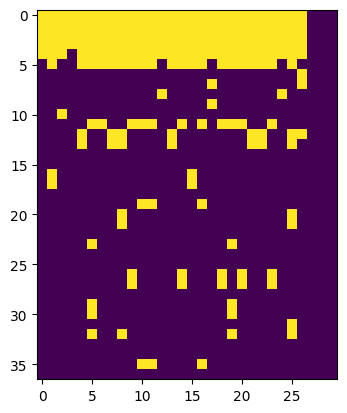

In [7]:
plt.imshow(atom_attention_mask[0].view(context_size, atom_slot_count).T.numpy())
atom_attention_mask.sum(dim=1)

tensor([218, 239])

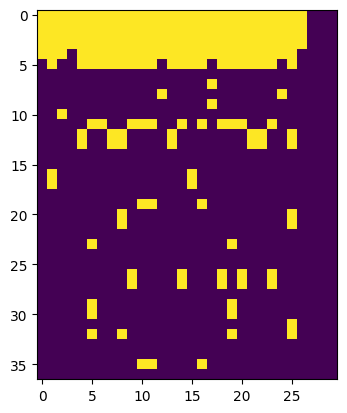

In [8]:
plt.imshow(coordinate_atom_mask[0].view(context_size, atom_slot_count).T.numpy())
coordinate_atom_mask.sum(dim=1)

### Select Representative Atoms

The confidence pair path needs one coordinate per residue so it can compare the predicted distance between every residue pair. We'll use CB when it exists, then CA, then the first reference atom.

In [9]:
positions = torch.arange(context_size).view(1, context_size).expand(batch_size, context_size)
cb_index = ATOM_SLOTS.index('CB')
ca_index = ATOM_SLOTS.index('CA')
first_valid_atom = reference_atom_mask_slots.float().argmax(dim=-1)
cb_atom_idx = positions * atom_slot_count + cb_index
ca_atom_idx = positions * atom_slot_count + ca_index

In [10]:
distogram_atom_idx = torch.where(
    reference_atom_mask_slots[:, :, cb_index],
    cb_atom_idx,
    torch.where(reference_atom_mask_slots[:, :, ca_index], ca_atom_idx, positions * atom_slot_count + first_valid_atom),
)

distogram_atom_idx.shape, distogram_atom_idx

(torch.Size([2, 30]),
 tensor([[   4,   41,   78,  112,  152,  189,  226,  263,  300,  337,  374,  411,
           448,  485,  522,  559,  596,  633,  670,  707,  744,  781,  818,  855,
           892,  929,  966,  999, 1036, 1073],
         [   4,   41,   78,  115,  152,  189,  226,  260,  300,  337,  374,  411,
           448,  485,  522,  559,  596,  633,  670,  704,  744,  781,  815,  855,
           892,  929,  966, 1003, 1040, 1077]]))

### Mock Folding-Core and Denoiser Outputs

Now we'll stage the learned values produced by the previous two notebooks. The variables we'll stage from both the folding core and diffusion head are:

* `x_inputs`: the per-residue input features generated by InputsEmbedder.
* `pair`: the recycled residue-pair representation from the recycling trunk.
* `relative_position_features`: the pairwise metadata encoding for residue, token, chain, and entity relationships generated by PairEmbedder.
* `token_bond_features`: the learned pair features built from cached token bonds.
* `pred_atom_coords`: the predicted coordinates being evaluated by the confidence head. These come from the one-step denoiser during folding training, a short diffusion rollout during confidence-head training, or the final diffusion sample during inference.

In [11]:
res_type_vocab_size = 33
profile_dim = res_type_vocab_size
deletion_dim = 1
atom_dim = 8
pair_dim = 8
single_dim = 12
inputs_dim = atom_dim + res_type_vocab_size + profile_dim + deletion_dim

distogram_bins = 10
plddt_bins = 10
pae_bins = 10
pde_bins = 10
pair_layers = 4
dropout = 0.2

inputs_dim, pair_layers, dropout

(75, 4, 0.2)

In [12]:
pair_mask = (token_attention_mask[:, :, None] & token_attention_mask[:, None, :]).unsqueeze(-1)
pair_mask.shape, pair_mask

(torch.Size([2, 30, 30, 1]),
 tensor([[[[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]],
 
          [[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]],
 
          [[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]],
 
          ...,
 
          [[False],
           [False],
           [False],
           ...,
           [False],
           [False],
           [False]],
 
          [[False],
           [False],
           [False],
           ...,
           [False],
           [False],
           [False]],
 
          [[False],
           [False],
           [False],
           ...,
           [False],
           [False],
           [False]]],
 
 
         [[[ True],
           [ True],
           [ True],
           ...,
           [ True],
           [ True],
 

In [13]:
x_inputs = torch.randn(batch_size, context_size, inputs_dim) * token_attention_mask.unsqueeze(-1)
x_inputs.shape, x_inputs

(torch.Size([2, 30, 75]),
 tensor([[[ 0.1808, -0.0700, -0.3596,  ...,  2.0089, -0.5370,  0.2228],
          [ 0.6971, -1.4267,  0.9059,  ..., -0.2912, -0.1140, -0.3137],
          [-0.6293,  1.1385, -0.9913,  ..., -0.5556, -0.3983, -0.5819],
          ...,
          [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
          [ 0.0000, -0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
         [[ 1.6110,  0.5486, -2.8114,  ..., -0.3942, -0.0968,  1.3060],
          [-1.2617, -0.0670,  0.2999,  ..., -0.2258, -0.9918, -1.0729],
          [-0.2498, -0.8868,  1.5427,  ...,  1.4538, -2.2956, -1.6489],
          ...,
          [-0.1257,  0.0723, -0.2567,  ...,  0.9110, -0.2684,  2.1700],
          [ 0.1898,  1.2052, -0.5015,  ...,  0.6370, -2.0427, -0.8035],
          [ 0.5114, -1.6066,  1.3145,  ..., -0.1013,  0.0042, -0.3833]]]))

In [14]:
pair = torch.randn(batch_size, context_size, context_size, pair_dim) * pair_mask
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.4528, -1.2867, -1.6834,  ...,  0.7593, -0.0086,  0.4140],
           [-0.3730,  2.1957, -0.4740,  ...,  0.2775, -0.3522,  0.5804],
           [ 2.2615,  1.2927,  0.7182,  ..., -0.4434,  0.1041,  0.0389],
           ...,
           [ 0.0000, -0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [ 0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [ 0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-2.3678,  1.2966, -0.4768,  ...,  0.4563, -0.3216,  1.5098],
           [-0.6557, -0.0333, -0.1869,  ..., -0.2232, -0.1270,  0.1994],
           [ 1.1425, -1.9429, -0.7968,  ..., -0.0658,  1.2351, -0.6777],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000]],
 
          [[ 0.2660, -1.7164, -0.2632,  ...,  1.8925, -0.

In [15]:
relative_position_features = torch.randn(batch_size, context_size, context_size, pair_dim) * pair_mask
relative_position_features.shape, relative_position_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.0296, -0.3462,  0.9152,  ..., -0.5038, -0.0654,  0.0264],
           [-0.7482,  0.5345, -1.5790,  ...,  0.7398, -0.2553, -0.3909],
           [-0.4828,  0.0338, -0.1034,  ..., -1.4367,  0.2124,  0.2744],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000]],
 
          [[ 2.5722,  2.0417, -0.5606,  ...,  1.2111, -1.7337,  1.4323],
           [ 1.0560,  1.1014, -0.5471,  ..., -1.1967,  0.9398,  1.1150],
           [ 0.6226, -0.2834,  0.0685,  ..., -0.2707, -0.1909, -1.8992],
           ...,
           [ 0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [ 0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000]],
 
          [[ 1.2007, -0.5920, -0.2890,  ...,  2.2516, -0.

In [16]:
token_bond_features = torch.randn(batch_size,context_size,context_size,pair_dim)
token_bond_features = token_bond_features * pair_mask
token_bond_features.shape, token_bond_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 7.4341e-01, -1.9383e+00,  1.3497e+00,  ...,  1.2566e+00,
             4.3728e-01,  9.6857e-01],
           [ 3.6254e-01, -7.3628e-01, -1.6153e-01,  ..., -3.7313e-01,
            -7.0051e-02,  3.0528e-01],
           [-9.0047e-01, -8.0938e-01, -1.3535e+00,  ..., -7.6514e-01,
            -1.3756e+00, -3.4013e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
             0.0000e+00, -0.0000e+00],
           [ 0.0000e+00, -0.0000e+00, -0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00, -0.0000e+00],
           [ 0.0000e+00, -0.0000e+00, -0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[-1.8667e+00, -7.2323e-01, -1.9579e-01,  ...,  1.3108e+00,
             5.3461e-01, -1.6025e+00],
           [ 1.1909e+00,  6.5455e-01,  1.1921e+00,  ..., -3.6984e-01,
            -5.0969e-01, -1.2950e+00],
           [-9.2514e-01, -1.3810e-01,  5.5872e-01,  ..., -2.0750e-01,
          

**Mock predicted coordinates**

We'll mock a denoised prediction by centering the deposited target and adding a small centered displacement to every reference atom row. This gives us an imperfect structure whose quality can become the confidence target later in the notebook. The confidence calculations are the same when these coordinates come from a short diffusion rollout.

In [17]:
def masked_center(coords, coord_mask):
    coordinate_values = coord_mask.to(dtype=coords.dtype)[..., None]
    center_dims = tuple(range(1, coords.ndim - 1))
    coordinate_count = coordinate_values.sum(
        dim=center_dims,
        keepdim=True,
    ).clamp_min(1.0)
    coordinate_center = (
        coords * coordinate_values
    ).sum(dim=center_dims, keepdim=True) / coordinate_count
    return (coords - coordinate_center) * coordinate_values

In [18]:
centered_target = masked_center(target_atom_coords, coordinate_atom_mask)
centered_target.shape, centered_target

(torch.Size([2, 1110, 3]),
 tensor([[[15.4715,  4.6908,  3.3178],
          [16.0345,  3.3448,  3.0798],
          [15.1015,  2.2098,  3.5078],
          ...,
          [-0.0000, -0.0000,  0.0000],
          [-0.0000, -0.0000,  0.0000],
          [-0.0000, -0.0000,  0.0000]],
 
         [[ 6.7871, -5.4255,  7.9648],
          [ 7.3431, -4.2545,  7.2378],
          [ 6.2131, -3.2525,  6.9668],
          ...,
          [-0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000]]]))

In [19]:
prediction_noise = torch.randn_like(centered_target) * atom_attention_mask.unsqueeze(-1)
prediction_center = prediction_noise.sum(dim=1, keepdim=True)
prediction_center = prediction_center / atom_attention_mask.sum(dim=1, keepdim=True).clamp_min(1).unsqueeze(-1)
prediction_noise = (prediction_noise - prediction_center) * atom_attention_mask.unsqueeze(-1)
prediction_noise.shape, prediction_noise

(torch.Size([2, 1110, 3]),
 tensor([[[-0.3754, -0.0603, -0.8210],
          [-0.2196, -0.5169, -0.1334],
          [ 0.1816,  0.1478, -0.9553],
          ...,
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]],
 
         [[ 0.7366, -0.4346,  0.1883],
          [-0.0086, -1.1618, -0.4813],
          [-0.6277, -0.4230,  1.5609],
          ...,
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000, -0.0000, -0.0000]]]))

In [20]:
pred_atom_coords = centered_target + 0.75 * prediction_noise
pred_atom_coords = pred_atom_coords.requires_grad_()
pred_atom_coords.shape, pred_atom_coords

(torch.Size([2, 1110, 3]),
 tensor([[[15.1899,  4.6456,  2.7021],
          [15.8698,  2.9571,  2.9798],
          [15.2377,  2.3207,  2.7913],
          ...,
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]],
 
         [[ 7.3395, -5.7514,  8.1060],
          [ 7.3366, -5.1258,  6.8768],
          [ 5.7423, -3.5697,  8.1375],
          ...,
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000]]], requires_grad=True))

**Detach coordinates before confidence**

During folding training, the one-step prediction belongs to the denoiser's gradient graph, so we detach the predicted coordinates before passing them into the confidence head. This keeps the confidence loss from training the denoiser through `pred_atom_coords`. The confidence loss can still train the confidence head and flow back through `x_inputs` and `pair`, while the separate confidence-head training stage freezes those earlier model components.

In [21]:
confidence_atom_coords = pred_atom_coords.detach()
torch.allclose(confidence_atom_coords, pred_atom_coords), confidence_atom_coords.shape, confidence_atom_coords

(True,
 torch.Size([2, 1110, 3]),
 tensor([[[15.1899,  4.6456,  2.7021],
          [15.8698,  2.9571,  2.9798],
          [15.2377,  2.3207,  2.7913],
          ...,
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]],
 
         [[ 7.3395, -5.7514,  8.1060],
          [ 7.3366, -5.1258,  6.8768],
          [ 5.7423, -3.5697,  8.1375],
          ...,
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000]]]))

## Confidence Head `ConfidenceHead`
<img src="explainer_screenshots/3c_confidencehead/overview.png" width="800">

Now we're ready to run our confidence head to estimate how trustworthy the predicted structure is. The confidence head rebuilds a confidence-specific residue-pair representation from the final recycled pair, the original metadata encodings, the predicted residue distances, and the residue input features. It then refines that pair representation and uses it to predict confidence at three levels:

1. Residue and atom confidence through predicted local Distance Difference Test (pLDDT)-style outputs
2. Residue-pair error through Predicted Aligned Error (PAE) and Predicted Distance Error (PDE) outputs
3. Resolved or unresolved atom status, which predicts whether each expected reference atom has a usable deposited coordinate in the target structure

The template modeling (TM)-style scores are calculated from the PAE probabilities rather than learned by a separate output layer. The predicted TM score (pTM) estimates overall fold quality, while the interface predicted TM score (ipTM) estimates accuracy between chains. For a single-chain protein, ipTM is not meaningful.

### Build Predicted Distance Features
<img src="explainer_screenshots/3c_confidencehead/predicted_distance.png" width="500">

We'll start by calculating the binned predicted-coordinate distance features. While this is similar to the distogram, instead of predicting the bin, we take the predicted coordinates and bin them. We then use each bin ID to select a learned embedding.

**Gather representative coordinates**

We'll use `distogram_atom_idx` to gather the predicted representative coordinate for each residue.

In [22]:
representative_index = distogram_atom_idx.clamp_min(0).unsqueeze(-1).expand(batch_size, context_size, 3)
representative_index.shape, representative_index

(torch.Size([2, 30, 3]),
 tensor([[[   4,    4,    4],
          [  41,   41,   41],
          [  78,   78,   78],
          [ 112,  112,  112],
          [ 152,  152,  152],
          [ 189,  189,  189],
          [ 226,  226,  226],
          [ 263,  263,  263],
          [ 300,  300,  300],
          [ 337,  337,  337],
          [ 374,  374,  374],
          [ 411,  411,  411],
          [ 448,  448,  448],
          [ 485,  485,  485],
          [ 522,  522,  522],
          [ 559,  559,  559],
          [ 596,  596,  596],
          [ 633,  633,  633],
          [ 670,  670,  670],
          [ 707,  707,  707],
          [ 744,  744,  744],
          [ 781,  781,  781],
          [ 818,  818,  818],
          [ 855,  855,  855],
          [ 892,  892,  892],
          [ 929,  929,  929],
          [ 966,  966,  966],
          [ 999,  999,  999],
          [1036, 1036, 1036],
          [1073, 1073, 1073]],
 
         [[   4,    4,    4],
          [  41,   41,   41],
          [ 

In [23]:
predicted_representative_coords = confidence_atom_coords.gather(dim=1, index=representative_index)
predicted_representative_coords.shape, predicted_representative_coords

(torch.Size([2, 30, 3]),
 tensor([[[ 17.1814,   2.6555,   4.0524],
          [ 13.0011,   0.9739,   6.7670],
          [ 12.4264,   5.7380,   3.1113],
          [  7.2967,   3.7101,   1.8620],
          [  8.7746,   0.2084,   2.0163],
          [  3.4097,   0.7369,   5.8895],
          [  5.1488,  -0.8535,   9.9012],
          [  1.0266,  -1.7400,  10.0040],
          [ -1.0269,  -2.3480,   4.7497],
          [  4.2708,  -0.2985,   1.7379],
          [  6.3152,  -4.2618,   7.5339],
          [  3.1819,  -6.3337,   9.0319],
          [  2.4362,  -8.8814,   2.0213],
          [ -2.8186,  -6.5061,   5.2765],
          [ -3.9997,  -1.8930,   0.7192],
          [ -4.9858,   1.0525,   4.3340],
          [-10.2733,   0.4293,   3.8749],
          [ -8.9358,   3.6462,  -0.5420],
          [ -2.9162,   1.8700,  -2.0336],
          [ -4.7672,  -1.1681,  -4.7759],
          [ -9.6630,   3.1904,  -5.0616],
          [ -3.2033,   5.1016,  -4.8389],
          [ -2.8472,   0.3966,  -8.5260],
         

**Calculate predicted distances**

Now we'll subtract every representative coordinate from every other representative coordinate and calculate the distance for each residue pair.

In [24]:
predicted_representative_deltas = predicted_representative_coords[:, :, None, :] - predicted_representative_coords[:, None, :, :]
predicted_distances = torch.sqrt((predicted_representative_deltas * predicted_representative_deltas).sum(dim=-1).clamp_min(0.0) + 1e-8)
predicted_distances.shape, predicted_distances

(torch.Size([2, 30, 30]),
 tensor([[[1.0000e-04, 5.2604e+00, 5.7444e+00,  ..., 1.7851e+01,
           1.7851e+01, 1.7851e+01],
          [5.2604e+00, 1.0000e-04, 6.0325e+00,  ..., 1.4689e+01,
           1.4689e+01, 1.4689e+01],
          [5.7444e+00, 6.0325e+00, 1.0000e-04,  ..., 1.4036e+01,
           1.4036e+01, 1.4036e+01],
          ...,
          [1.7851e+01, 1.4689e+01, 1.4036e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.7851e+01, 1.4689e+01, 1.4036e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.7851e+01, 1.4689e+01, 1.4036e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04]],
 
         [[1.0000e-04, 6.7642e+00, 8.6993e+00,  ..., 2.1024e+01,
           2.5380e+01, 2.5001e+01],
          [6.7642e+00, 1.0000e-04, 3.7128e+00,  ..., 1.9488e+01,
           2.2757e+01, 2.2000e+01],
          [8.6993e+00, 3.7128e+00, 1.0000e-04,  ..., 2.0239e+01,
           2.3280e+01, 2.2649e+01],
          ...,
          [2.1024e+01, 1.9488e+0

**Embed distance bins**

We'll place each distance into a bin and embed the bins.

In [25]:
confidence_dist_boundaries = torch.linspace(2.0, 22.0, distogram_bins - 1)
confidence_dist_boundaries.shape, confidence_dist_boundaries

(torch.Size([9]),
 tensor([ 2.0000,  4.5000,  7.0000,  9.5000, 12.0000, 14.5000, 17.0000, 19.5000,
         22.0000]))

In [26]:
distance_bins = torch.bucketize(predicted_distances.contiguous(), confidence_dist_boundaries)
distance_bins.shape, distance_bins

(torch.Size([2, 30, 30]),
 tensor([[[0, 2, 2,  ..., 7, 7, 7],
          [2, 0, 2,  ..., 6, 6, 6],
          [2, 2, 0,  ..., 5, 5, 5],
          ...,
          [7, 6, 5,  ..., 0, 0, 0],
          [7, 6, 5,  ..., 0, 0, 0],
          [7, 6, 5,  ..., 0, 0, 0]],
 
         [[0, 2, 3,  ..., 8, 9, 9],
          [2, 0, 1,  ..., 7, 9, 9],
          [3, 1, 0,  ..., 8, 9, 9],
          ...,
          [8, 7, 8,  ..., 0, 2, 2],
          [9, 9, 9,  ..., 2, 0, 1],
          [9, 9, 9,  ..., 2, 1, 0]]]))

In [27]:
distance_bin_embedding = nn.Embedding(distogram_bins, pair_dim)
distance_embeddings = distance_bin_embedding(distance_bins)
distance_embeddings.shape, distance_embeddings

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.6485,  0.7316,  0.5241,  ...,  0.8482,  0.1936,  1.0491],
           [ 0.0357, -1.2610,  0.6685,  ..., -0.9515, -2.4788,  0.7231],
           [ 0.0357, -1.2610,  0.6685,  ..., -0.9515, -2.4788,  0.7231],
           ...,
           [-0.0649,  0.0824, -1.2106,  ...,  1.0240,  0.4451,  0.2464],
           [-0.0649,  0.0824, -1.2106,  ...,  1.0240,  0.4451,  0.2464],
           [-0.0649,  0.0824, -1.2106,  ...,  1.0240,  0.4451,  0.2464]],
 
          [[ 0.0357, -1.2610,  0.6685,  ..., -0.9515, -2.4788,  0.7231],
           [-1.6485,  0.7316,  0.5241,  ...,  0.8482,  0.1936,  1.0491],
           [ 0.0357, -1.2610,  0.6685,  ..., -0.9515, -2.4788,  0.7231],
           ...,
           [ 0.1318, -0.4001, -2.1011,  ..., -1.4679,  0.6271,  0.4251],
           [ 0.1318, -0.4001, -2.1011,  ..., -1.4679,  0.6271,  0.4251],
           [ 0.1318, -0.4001, -2.1011,  ..., -1.4679,  0.6271,  0.4251]],
 
          [[ 0.0357, -1.2610,  0.6685,  ..., -0.9515, -2.

### Build the Confidence Pair
<img src="explainer_screenshots/3c_confidencehead/confidence_pair.png" width="500">

We now need to build out the residue-pair relationships that the confidence head will use to evaluate our predicted coordinates. We start with the final pair representation from the recycling trunk, normalize it, and add the relative-position features, token-bond features, and predicted-distance embedding. This gives the confidence head both the folding trunk's learned pair relationships and direct information about the structure it is being asked to evaluate.

In [28]:
confidence_pair_norm = nn.LayerNorm(pair_dim)
confidence_pair = confidence_pair_norm(pair)
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-3.7442e-01, -1.3228e+00, -1.7741e+00,  ...,  1.0041e+00,
             1.3084e-01,  6.1138e-01],
           [-3.8019e-01,  2.2708e+00, -4.8439e-01,  ...,  2.9115e-01,
            -3.5873e-01,  6.0374e-01],
           [ 2.0589e+00,  8.9746e-01,  2.0883e-01,  ..., -1.1837e+00,
            -5.2739e-01, -6.0551e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[-2.0551e+00,  1.1765e+00, -3.8745e-01,  ...,  4.3545e-01,
            -2.5056e-01,  1.3645e+00],
           [-1.2020e+00, -1.8027e-01, -4.3238e-01,  ..., -4.9195e-01,
            -3.3408e-01,  2.0183e-01],
           [ 1.3539e+00, -1.8068e+00, -6.3273e-01,  ...,  1.1614e-01,
          

In [29]:
confidence_pair = (confidence_pair + 
                   relative_position_features +
                   token_bond_features +
                   distance_embeddings)
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.2499, -2.8757,  1.0149,  ...,  2.6052,  0.6963,  2.6555],
           [-0.7302,  0.8079, -1.5564,  ..., -0.2937, -3.1628,  1.2412],
           [ 0.7113, -1.1392, -0.5796,  ..., -4.3371, -4.1693,  0.0519],
           ...,
           [-0.0649,  0.0824, -1.2106,  ...,  1.0240,  0.4451,  0.2464],
           [-0.0649,  0.0824, -1.2106,  ...,  1.0240,  0.4451,  0.2464],
           [-0.0649,  0.0824, -1.2106,  ...,  1.0240,  0.4451,  0.2464]],
 
          [[-1.3140,  1.2339, -0.4753,  ...,  2.0059, -3.9284,  1.9174],
           [-0.6036,  2.3072,  0.7367,  ..., -1.2103,  0.2896,  1.0710],
           [ 1.0870, -3.4893,  0.6630,  ..., -1.3135, -1.6782,  0.3189],
           ...,
           [ 0.1318, -0.4001, -2.1011,  ..., -1.4679,  0.6271,  0.4251],
           [ 0.1318, -0.4001, -2.1011,  ..., -1.4679,  0.6271,  0.4251],
           [ 0.1318, -0.4001, -2.1011,  ..., -1.4679,  0.6271,  0.4251]],
 
          [[ 2.5403, -3.6155, -1.1292,  ...,  4.0281, -3.

### Add Residue Input Relationships
<img src="explainer_screenshots/3c_confidencehead/input_relationship.png" width="800">

Next we'll add three views of `x_inputs` to the confidence pair. One projection broadcasts residue $i$ across each row, another broadcasts residue $j$ down each column, and the final is a product that lets the model learn features that only become active when the two residue projections interact. This gives each pair position direct access to both residue inputs in addition to the recycled pair and predicted distance. We'll first normalize, then create and add the three projections to our confidence pair representation.

**Normalize the residue inputs**

We'll first normalize `x_inputs` before using it to build the residue-pair relationships.

In [30]:
confidence_inputs_norm = nn.LayerNorm(inputs_dim)
normalized_inputs = confidence_inputs_norm(x_inputs)
normalized_inputs.shape, normalized_inputs

(torch.Size([2, 30, 75]),
 tensor([[[ 0.0722, -0.1666, -0.4424,  ...,  1.8133, -0.6113,  0.1122],
          [ 0.6634, -1.3568,  0.8621,  ..., -0.2767, -0.1081, -0.2980],
          [-0.6554,  1.1209, -1.0191,  ..., -0.5813, -0.4232, -0.6077],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 1.5734,  0.4646, -3.0423,  ..., -0.5195, -0.2090,  1.2551],
          [-1.4123, -0.0372,  0.3850,  ..., -0.2201, -1.1017, -1.1950],
          [-0.3411, -1.0118,  1.5464,  ...,  1.4527, -2.4952, -1.8142],
          ...,
          [-0.4086, -0.1959, -0.5493,  ...,  0.7050, -0.5618,  2.0574],
          [ 0.0492,  1.0502, -0.6324,  ...,  0.4901, -2.1519, -0.9302],
          [ 0.5744, -1.7439,  1.4535,  ..., -0.0962,  0.0193, -0.4049]]],
        grad_fn=<NativeLayerNormBackward0>))

**Build and add row feature**

We'll start with the row feature. We project each residue input into the pair width, then add a new axis so residue $i$ is repeated across every pair $(i,j)$ in its row. We then add that row feature to our confidence pair.

In [31]:
single_to_pair_a = nn.Linear(inputs_dim, pair_dim, bias=False)
confidence_row = single_to_pair_a(normalized_inputs)
confidence_row.shape, confidence_row

(torch.Size([2, 30, 8]),
 tensor([[[-0.7846, -0.4895,  0.1696, -0.4954, -0.0215,  0.2477,  0.2646,
           -0.5018],
          [ 1.2882,  1.1267,  0.0839,  0.0806, -0.1884, -0.2630,  0.7082,
           -0.5062],
          [-0.5671, -0.4956, -0.0680, -0.5965, -0.9782, -0.0941, -0.3180,
            0.1196],
          [-0.8743, -0.2676,  0.1448,  0.1776,  0.0476, -0.3304, -0.7524,
            0.2699],
          [ 0.9665,  0.2396,  0.9573,  1.5322,  0.0747, -0.4681,  0.7134,
           -0.4594],
          [ 1.1924, -1.1595, -0.1792,  0.1335,  0.9007,  0.0955,  0.2614,
            0.7709],
          [-0.2822,  0.9994, -0.1725, -0.5092,  0.2498, -0.6607,  0.3443,
            0.6169],
          [ 0.5830, -0.0730, -1.1032, -0.3337,  0.8018,  0.1262, -0.5426,
            0.5450],
          [ 1.0621,  1.2523, -1.2020, -1.7563,  0.1842, -0.1750, -1.0790,
            0.2848],
          [-0.5355, -1.0054, -0.0924,  0.5598,  0.1800, -0.8458,  0.1727,
            0.0949],
          [-0.4815,  0.34

In [32]:
confidence_row = confidence_row.unsqueeze(2)
confidence_row.shape, confidence_row

(torch.Size([2, 30, 1, 8]),
 tensor([[[[-0.7846, -0.4895,  0.1696, -0.4954, -0.0215,  0.2477,  0.2646,
            -0.5018]],
 
          [[ 1.2882,  1.1267,  0.0839,  0.0806, -0.1884, -0.2630,  0.7082,
            -0.5062]],
 
          [[-0.5671, -0.4956, -0.0680, -0.5965, -0.9782, -0.0941, -0.3180,
             0.1196]],
 
          [[-0.8743, -0.2676,  0.1448,  0.1776,  0.0476, -0.3304, -0.7524,
             0.2699]],
 
          [[ 0.9665,  0.2396,  0.9573,  1.5322,  0.0747, -0.4681,  0.7134,
            -0.4594]],
 
          [[ 1.1924, -1.1595, -0.1792,  0.1335,  0.9007,  0.0955,  0.2614,
             0.7709]],
 
          [[-0.2822,  0.9994, -0.1725, -0.5092,  0.2498, -0.6607,  0.3443,
             0.6169]],
 
          [[ 0.5830, -0.0730, -1.1032, -0.3337,  0.8018,  0.1262, -0.5426,
             0.5450]],
 
          [[ 1.0621,  1.2523, -1.2020, -1.7563,  0.1842, -0.1750, -1.0790,
             0.2848]],
 
          [[-0.5355, -1.0054, -0.0924,  0.5598,  0.1800, -0.8458,  0.172

In [33]:
confidence_pair = confidence_pair + confidence_row
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-2.0345, -3.3652,  1.1845,  ...,  2.8529,  0.9610,  2.1537],
           [-1.5148,  0.3184, -1.3868,  ..., -0.0460, -2.8982,  0.7394],
           [-0.0734, -1.6287, -0.4100,  ..., -4.0894, -3.9046, -0.4499],
           ...,
           [-0.8495, -0.4071, -1.0410,  ...,  1.2717,  0.7097, -0.2554],
           [-0.8495, -0.4071, -1.0410,  ...,  1.2717,  0.7097, -0.2554],
           [-0.8495, -0.4071, -1.0410,  ...,  1.2717,  0.7097, -0.2554]],
 
          [[-0.0258,  2.3606, -0.3915,  ...,  1.7429, -3.2202,  1.4112],
           [ 0.6847,  3.4339,  0.8205,  ..., -1.4732,  0.9977,  0.5648],
           [ 2.3752, -2.3626,  0.7468,  ..., -1.5765, -0.9700, -0.1873],
           ...,
           [ 1.4200,  0.7266, -2.0172,  ..., -1.7309,  1.3353, -0.0811],
           [ 1.4200,  0.7266, -2.0172,  ..., -1.7309,  1.3353, -0.0811],
           [ 1.4200,  0.7266, -2.0172,  ..., -1.7309,  1.3353, -0.0811]],
 
          [[ 1.9732, -4.1111, -1.1972,  ...,  3.9340, -4.

**Build and add column feature**

Next we'll build the column feature. We project each residue input into the pair width, then add a new axis so residue $j$ is repeated across every pair $(i,j)$ in its column. We then add that column feature to our confidence pair.

In [34]:
single_to_pair_b = nn.Linear(inputs_dim, pair_dim, bias=False)
confidence_column = single_to_pair_b(normalized_inputs)
confidence_column.shape, confidence_column

(torch.Size([2, 30, 8]),
 tensor([[[-2.2510e-02,  2.7782e-01, -1.0337e+00, -7.1866e-01,  3.8926e-01,
            9.5288e-01, -1.0870e+00, -6.6012e-01],
          [ 4.5287e-01,  8.6857e-01, -1.3270e+00, -3.0084e-01, -4.3031e-01,
            4.4933e-01,  3.8726e-02, -5.0244e-01],
          [ 2.1278e-01, -6.7408e-03, -2.1411e-01, -1.7127e+00,  3.9150e-01,
            4.9754e-02, -5.0562e-01,  2.2822e-02],
          [-1.8094e-01, -7.6633e-01,  7.8116e-02, -8.6053e-02, -4.0263e-01,
           -4.8152e-01,  7.8932e-02, -6.8509e-01],
          [-2.8208e-02, -8.2230e-01,  5.7915e-01, -8.0850e-01, -2.1550e-01,
           -4.9072e-01, -4.0977e-02,  4.1372e-01],
          [ 2.1937e-01,  7.2209e-01, -4.7890e-01,  1.7393e-01, -8.3070e-02,
            8.8243e-01, -1.5582e+00, -3.5892e-01],
          [ 1.5318e+00,  1.6494e-01,  8.4824e-01,  4.6814e-01,  1.7532e-01,
            2.2885e-01,  7.5875e-02, -1.7516e-01],
          [ 8.2593e-01,  1.7005e+00,  6.5775e-01, -6.1920e-01, -9.0247e-01,
          

In [35]:
confidence_column = confidence_column.unsqueeze(1)
confidence_column.shape, confidence_column

(torch.Size([2, 1, 30, 8]),
 tensor([[[[-2.2510e-02,  2.7782e-01, -1.0337e+00, -7.1866e-01,  3.8926e-01,
             9.5288e-01, -1.0870e+00, -6.6012e-01],
           [ 4.5287e-01,  8.6857e-01, -1.3270e+00, -3.0084e-01, -4.3031e-01,
             4.4933e-01,  3.8726e-02, -5.0244e-01],
           [ 2.1278e-01, -6.7408e-03, -2.1411e-01, -1.7127e+00,  3.9150e-01,
             4.9754e-02, -5.0562e-01,  2.2822e-02],
           [-1.8094e-01, -7.6633e-01,  7.8116e-02, -8.6053e-02, -4.0263e-01,
            -4.8152e-01,  7.8932e-02, -6.8509e-01],
           [-2.8208e-02, -8.2230e-01,  5.7915e-01, -8.0850e-01, -2.1550e-01,
            -4.9072e-01, -4.0977e-02,  4.1372e-01],
           [ 2.1937e-01,  7.2209e-01, -4.7890e-01,  1.7393e-01, -8.3070e-02,
             8.8243e-01, -1.5582e+00, -3.5892e-01],
           [ 1.5318e+00,  1.6494e-01,  8.4824e-01,  4.6814e-01,  1.7532e-01,
             2.2885e-01,  7.5875e-02, -1.7516e-01],
           [ 8.2593e-01,  1.7005e+00,  6.5775e-01, -6.1920e-01, -9.02

In [36]:
confidence_pair = confidence_pair + confidence_column
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-2.0570e+00, -3.0874e+00,  1.5078e-01,  ...,  3.8058e+00,
            -1.2604e-01,  1.4936e+00],
           [-1.0619e+00,  1.1870e+00, -2.7138e+00,  ...,  4.0336e-01,
            -2.8594e+00,  2.3693e-01],
           [ 1.3943e-01, -1.6354e+00, -6.2413e-01,  ..., -4.0396e+00,
            -4.4103e+00, -4.2712e-01],
           ...,
           [-8.4952e-01, -4.0713e-01, -1.0410e+00,  ...,  1.2717e+00,
             7.0969e-01, -2.5540e-01],
           [-8.4952e-01, -4.0713e-01, -1.0410e+00,  ...,  1.2717e+00,
             7.0969e-01, -2.5540e-01],
           [-8.4952e-01, -4.0713e-01, -1.0410e+00,  ...,  1.2717e+00,
             7.0969e-01, -2.5540e-01]],
 
          [[-4.8261e-02,  2.6385e+00, -1.4252e+00,  ...,  2.6958e+00,
            -4.3072e+00,  7.5109e-01],
           [ 1.1375e+00,  4.3025e+00, -5.0647e-01,  ..., -1.0239e+00,
             1.0365e+00,  6.2310e-02],
           [ 2.5880e+00, -2.3693e+00,  5.3273e-01,  ..., -1.5268e+00,
          

**Build and add product feature**

We'll finally add the product feature. This creates two projections, combines them into a pairwise interaction, and projects that interaction. Once we have that, we add it to our confidence pair, letting it learn from the interaction of two residues. After we add the projected product feature, we'll apply our mask to keep padded residue pairs at zero.

In [37]:
single_to_pair_prod_a = nn.Linear(inputs_dim, pair_dim, bias=False)
confidence_product_a = single_to_pair_prod_a(normalized_inputs).unsqueeze(2)
confidence_product_a.shape, confidence_product_a

(torch.Size([2, 30, 1, 8]),
 tensor([[[[-0.8212,  0.0650,  0.7220,  1.0702, -0.0704,  0.5227,  0.1023,
             1.0365]],
 
          [[-0.0461, -0.5518, -0.2458,  0.3891,  0.0018,  0.0408,  0.0701,
             0.2967]],
 
          [[-0.4805, -0.4161,  0.7040, -0.3319,  0.2026, -0.1224, -0.6458,
            -0.6710]],
 
          [[-0.0326, -0.1539,  0.0571, -0.1586,  0.2889, -0.3417, -0.2986,
            -0.0340]],
 
          [[-1.2544, -0.5360,  0.1668, -0.3051,  0.8828, -0.4973, -0.0964,
            -0.6521]],
 
          [[-0.1377, -0.7194,  1.2199, -1.2861, -0.5365, -0.7085,  1.0026,
             0.6123]],
 
          [[ 0.4007,  0.4239,  0.4785, -0.6112,  0.7880,  0.4625, -0.1359,
             0.1993]],
 
          [[-0.9695, -0.0619, -0.0735,  0.7585, -0.4865, -0.1183, -0.4510,
             0.2336]],
 
          [[ 0.2197,  0.7220, -0.0184, -1.2087,  0.6051,  0.3143, -0.6666,
             0.4901]],
 
          [[-0.1442, -0.5352,  0.2656, -0.7442, -0.7924, -0.2679,  0.459

In [38]:
single_to_pair_prod_b = nn.Linear(inputs_dim, pair_dim, bias=False)
confidence_product_b = single_to_pair_prod_b(normalized_inputs).unsqueeze(1)
confidence_product_b.shape, confidence_product_b

(torch.Size([2, 1, 30, 8]),
 tensor([[[[ 4.2778e-01,  2.5741e-01,  1.1662e+00,  3.9505e-01,  4.6874e-01,
             9.4306e-01, -2.2465e-01,  4.8868e-01],
           [-4.9583e-01, -7.1243e-01, -8.2968e-01, -4.8942e-02,  8.1120e-02,
            -4.0956e-01, -9.1248e-02, -2.6417e-01],
           [ 3.7948e-01, -8.0799e-01,  1.1163e-01,  1.3526e-01, -7.9880e-01,
            -4.3311e-01,  1.0427e-01, -4.9938e-01],
           [ 4.4784e-01, -8.5141e-01, -8.8440e-02,  5.0558e-02,  5.4681e-01,
            -3.6183e-01, -3.8923e-01,  3.0756e-01],
           [-9.1651e-01, -9.2299e-01,  1.7056e-01,  2.2628e-01, -8.0454e-01,
            -1.4073e-02,  3.3724e-02,  3.8897e-01],
           [ 1.9785e-02,  5.1005e-01, -4.2513e-01, -1.0417e+00, -2.9279e-01,
            -3.4984e-02,  3.9101e-01,  1.8702e-01],
           [ 3.4057e-02, -1.8629e-01,  1.2289e+00,  1.1998e+00, -5.1055e-01,
            -3.2028e-02,  7.7722e-01, -2.5394e-01],
           [ 8.4290e-02, -2.9516e-02, -1.2823e-01,  9.9026e-01,  3.94

In [39]:
confidence_product = confidence_product_a * confidence_product_b
confidence_product.shape, confidence_product

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-3.5128e-01,  1.6724e-02,  8.4197e-01,  ...,  4.9298e-01,
            -2.2975e-02,  5.0653e-01],
           [ 4.0716e-01, -4.6285e-02, -5.9899e-01,  ..., -2.1410e-01,
            -9.3321e-03, -2.7382e-01],
           [-3.1161e-01, -5.2494e-02,  8.0592e-02,  ..., -2.2640e-01,
             1.0663e-02, -5.1762e-01],
           ...,
           [-0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [-0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [-0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[-1.9731e-02, -1.4204e-01, -2.8661e-01,  ...,  3.8502e-02,
            -1.5742e-02,  1.4497e-01],
           [ 2.2870e-02,  3.9313e-01,  2.0390e-01,  ..., -1.6721e-02,
            -6.3940e-03, -7.8369e-02],
           [-1.7504e-02,  4.4587e-01, -2.7434e-02,  ..., -1.7682e-02,
          

In [40]:
single_to_pair_prod_out = nn.Linear(pair_dim, pair_dim, bias=False)
confidence_product = single_to_pair_prod_out(confidence_product)
confidence_product.shape, confidence_product

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.0999, -0.2170, -0.4734,  ...,  0.2388, -0.1638,  0.3261],
           [-0.0966,  0.0160,  0.2944,  ..., -0.1368,  0.1424, -0.1524],
           [ 0.3184,  0.1748,  0.0904,  ...,  0.0064,  0.0425,  0.0965],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.0203, -0.1015, -0.0191,  ..., -0.0579,  0.1781, -0.0571],
           [-0.0702, -0.0138,  0.0415,  ..., -0.0041, -0.2085,  0.0090],
           [-0.0870, -0.0489,  0.1050,  ..., -0.0832, -0.1411, -0.0570],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.3513,  0.2466, -0.1191,  ...,  0.2289, -0.

In [41]:
confidence_pair = confidence_pair + confidence_product
confidence_pair = confidence_pair * pair_mask
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.9572, -3.3044, -0.3226,  ...,  4.0446, -0.2898,  1.8197],
           [-1.1585,  1.2030, -2.4193,  ...,  0.2666, -2.7170,  0.0846],
           [ 0.4578, -1.4607, -0.5337,  ..., -4.0333, -4.3677, -0.3306],
           ...,
           [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
          [[-0.0686,  2.5370, -1.4442,  ...,  2.6379, -4.1291,  0.6940],
           [ 1.0674,  4.2887, -0.4650,  ..., -1.0280,  0.8280,  0.0713],
           [ 2.5010, -2.4183,  0.6378,  ..., -1.6100, -1.6168, -0.2215],
           ...,
           [ 0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [ 0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [ 0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
          [[ 2.3019, -3.5867, -2.3500,  ...,  5.1158, -5.

### Confidence Pair Trunk `PairBlock`
<img src="explainer_screenshots/3c_confidencehead/pairblock.png" width="800">

Now that we have built a new pair representation, the confidence head runs a set of sequential pair blocks to allow a pair of residues to exchange information with a third residue. The output of each block becomes the input to the next block, so the pair keeps the same shape while each block refines its values with its own learned parameters. Our configuration runs two confidence pair blocks, but we'll unfold one block since the second repeats the same operations. This is the same `PairBlock` class that we used in the recycling trunk, so we'll go through it more quickly. We'll actually instantiate the `TriangleMultiplicativeUpdate` class and call it for our outgoing and incoming triangles. If you want a detailed breakdown, review the recycling trunk in notebook 3a.

We'll start by instantiating the class.

In [42]:
class TriangleMultiplicativeUpdate(nn.Module):
    def __init__(self, pair_dim, flow):
        super().__init__()
        assert flow in {'outgoing', 'incoming'}
        self.flow = flow
        self.norm = nn.LayerNorm(pair_dim)
        self.value_a = nn.Linear(pair_dim, pair_dim)
        self.value_b = nn.Linear(pair_dim, pair_dim)
        self.gate_a = nn.Linear(pair_dim, pair_dim)
        self.gate_b = nn.Linear(pair_dim, pair_dim)
        self.output_gate = nn.Linear(pair_dim, pair_dim)
        self.output = nn.Linear(pair_dim, pair_dim)

    def forward(self, pair, pair_mask):
        normalized = self.norm(pair)
        pair_mask_values = pair_mask.to(pair.dtype)

        first_values = torch.sigmoid(self.gate_a(normalized)) * self.value_a(normalized)
        second_values = torch.sigmoid(self.gate_b(normalized)) * self.value_b(normalized)

        first_values = first_values * pair_mask_values
        second_values = second_values * pair_mask_values

        first_values_by_channel = first_values.permute(0, 3, 1, 2)
        second_values_by_channel = second_values.permute(0, 3, 1, 2)

        if self.flow == 'outgoing':
            triangle_features = first_values_by_channel @ second_values_by_channel.transpose(-2, -1)
        else:
            triangle_features = first_values_by_channel.transpose(-2, -1) @ second_values_by_channel

        triangle_features = triangle_features.permute(0, 2, 3, 1)

        shared_residue_count = pair_mask.squeeze(-1).any(dim=2).sum(dim=1).to(pair.dtype).clamp_min(1.0)
        triangle_features = triangle_features / torch.sqrt(shared_residue_count)[:, None, None, None]

        output_gate = torch.sigmoid(self.output_gate(normalized))
        update = self.output(triangle_features) * output_gate * pair_mask_values

        return update

#### Outgoing Triangle Update `TriangleMultiplicativeUpdate`

We'll start with the outgoing update. For the outgoing triangle update, the model updates pair $(i, j)$ by looking at every intermediate residue $k$ and combining the relationships $(i, k)$ and $(j, k)$.

In [43]:
confidence_outgoing_triangle = TriangleMultiplicativeUpdate(pair_dim, flow='outgoing')
confidence_outgoing_output = confidence_outgoing_triangle(confidence_pair, pair_mask)
confidence_outgoing_output.shape, confidence_outgoing_output

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.1430, -0.0830,  0.0281,  ..., -0.1221, -0.1904,  0.0326],
           [-0.0316, -0.0678, -0.1015,  ..., -0.1275, -0.3148,  0.0448],
           [-0.0860, -0.0610, -0.0934,  ..., -0.1013, -0.2691,  0.0347],
           ...,
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000]],
 
          [[-0.0344, -0.0720, -0.0901,  ..., -0.1068, -0.2663,  0.0155],
           [-0.0820, -0.1154,  0.0048,  ..., -0.2023, -0.4512,  0.0103],
           [-0.0694, -0.0827, -0.0982,  ..., -0.0864, -0.2518,  0.0253],
           ...,
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000]],
 
          [[-0.1165, -0.0589, -0.0908,  ..., -0.0532, -0.

#### Update Confidence Pair With Outgoing

Now that we have our outgoing update ready, we'll add it to our pair before calculating the incoming update. We add the outgoing update first because this lets the two triangle directions build on each other instead of reading from the same older pair state. This also acts as a residual connection to allow gradients to bypass the outgoing update.

In [44]:
confidence_pair = confidence_pair + confidence_outgoing_output
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-2.1002e+00, -3.3874e+00, -2.9444e-01,  ...,  3.9225e+00,
            -4.8023e-01,  1.8523e+00],
           [-1.1900e+00,  1.1352e+00, -2.5208e+00,  ...,  1.3909e-01,
            -3.0319e+00,  1.2942e-01],
           [ 3.7182e-01, -1.5217e+00, -6.2707e-01,  ..., -4.1346e+00,
            -4.6369e+00, -2.9589e-01],
           ...,
           [-0.0000e+00, -0.0000e+00, -0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [-0.0000e+00, -0.0000e+00, -0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [-0.0000e+00, -0.0000e+00, -0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[-1.0299e-01,  2.4650e+00, -1.5343e+00,  ...,  2.5311e+00,
            -4.3954e+00,  7.0945e-01],
           [ 9.8539e-01,  4.1733e+00, -4.6020e-01,  ..., -1.2302e+00,
             3.7675e-01,  8.1644e-02],
           [ 2.4316e+00, -2.5010e+00,  5.3959e-01,  ..., -1.6964e+00,
          

#### Incoming Triangle Update

Next we'll calculate the incoming relationship. The calculation is similar to the outgoing update, with the main difference being that we transpose the first value instead of the second. This means that for the incoming triangle update, the model updates pair $(i, j)$ by looking at every intermediate residue $k$ and combining the relationships $(k, i)$ and $(k, j)$.

In [45]:
confidence_incoming_triangle = TriangleMultiplicativeUpdate(pair_dim, flow='incoming')
confidence_incoming_output = confidence_incoming_triangle(confidence_pair, pair_mask)
confidence_incoming_output.shape, confidence_incoming_output

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 1.5089e-01,  8.3215e-02, -4.6319e-02,  ..., -4.8469e-02,
             9.5138e-02, -1.6017e-01],
           [ 1.1974e-01,  8.7179e-02, -3.0098e-02,  ..., -1.2377e-01,
             1.0925e-01, -7.9523e-02],
           [ 8.2310e-02,  1.6974e-01,  2.8099e-02,  ..., -7.1594e-02,
             1.5905e-01, -4.8556e-02],
           ...,
           [ 0.0000e+00,  0.0000e+00, -0.0000e+00,  ..., -0.0000e+00,
             0.0000e+00, -0.0000e+00],
           [ 0.0000e+00,  0.0000e+00, -0.0000e+00,  ..., -0.0000e+00,
             0.0000e+00, -0.0000e+00],
           [ 0.0000e+00,  0.0000e+00, -0.0000e+00,  ..., -0.0000e+00,
             0.0000e+00, -0.0000e+00]],
 
          [[ 1.6712e-01,  1.2257e-01,  4.2769e-03,  ..., -1.2277e-01,
             1.5269e-01, -1.4507e-01],
           [-3.0405e-02,  2.4473e-01, -1.4090e-01,  ...,  1.5756e-02,
             1.4997e-01, -3.2753e-01],
           [ 5.9525e-02,  1.4503e-01,  5.7887e-02,  ..., -1.1049e-01,
          

#### Update Confidence Pair With Incoming

Now we'll add our incoming update to the pair. The outgoing update let each pair collect relationships pointing toward an intermediate residue, while this incoming update adds the opposite triangle direction. Since we add the update back to the existing pair, this also creates a residual connection around the incoming calculation.

In [46]:
confidence_pair = confidence_pair + confidence_incoming_output
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.9493, -3.3042, -0.3408,  ...,  3.8740, -0.3851,  1.6921],
           [-1.0703,  1.2224, -2.5509,  ...,  0.0153, -2.9226,  0.0499],
           [ 0.4541, -1.3519, -0.5990,  ..., -4.2062, -4.4778, -0.3445],
           ...,
           [ 0.0000,  0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.0641,  2.5875, -1.5300,  ...,  2.4083, -4.2427,  0.5644],
           [ 0.9550,  4.4180, -0.6011,  ..., -1.2145,  0.5267, -0.2459],
           [ 2.4912, -2.3559,  0.5975,  ..., -1.8069, -1.7182, -0.2601],
           ...,
           [ 0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0000]],
 
          [[ 2.3369, -3.5559, -2.4994,  ...,  5.0156, -5.

#### Confidence Pair SwiGLU MLP

Now that we have included our incoming and outgoing triangle relationships, we want to allow the channels to mix so that the model can decide how best to weight the different residue channel interactions. We'll do this using a simple SwiGLU-based feed-forward network with dropout. Dropout is active during training and turns off during inference.

In [47]:
confidence_transition_norm = nn.LayerNorm(pair_dim)
confidence_transition_fc = nn.Linear(pair_dim, 8 * pair_dim)
confidence_gate, confidence_values = confidence_transition_fc(confidence_transition_norm(confidence_pair)).chunk(2, dim=-1)

In [48]:
confidence_gate.shape, confidence_gate

(torch.Size([2, 30, 30, 32]),
 tensor([[[[ 0.2676, -0.1820, -0.3334,  ..., -1.0151, -0.1055, -0.0567],
           [ 0.8402, -0.3290, -0.7903,  ..., -1.0228, -0.2898, -0.5835],
           [-0.0490,  0.7933, -0.7930,  ...,  0.2992, -0.0301,  0.0611],
           ...,
           [ 0.1938, -0.2185, -0.1740,  ..., -0.1570,  0.1823, -0.0077],
           [ 0.1938, -0.2185, -0.1740,  ..., -0.1570,  0.1823, -0.0077],
           [ 0.1938, -0.2185, -0.1740,  ..., -0.1570,  0.1823, -0.0077]],
 
          [[ 0.3024, -0.4023, -0.3155,  ..., -1.0634, -0.6582, -0.7548],
           [ 0.0171, -0.6731,  0.1572,  ...,  0.4271, -0.1068,  0.4760],
           [-0.7324,  0.3348,  0.2293,  ...,  0.6103, -0.2695,  0.3397],
           ...,
           [ 0.1938, -0.2185, -0.1740,  ..., -0.1570,  0.1823, -0.0077],
           [ 0.1938, -0.2185, -0.1740,  ..., -0.1570,  0.1823, -0.0077],
           [ 0.1938, -0.2185, -0.1740,  ..., -0.1570,  0.1823, -0.0077]],
 
          [[-0.1340, -0.1550, -0.1022,  ..., -0.7692, -0

In [49]:
confidence_values.shape, confidence_values

(torch.Size([2, 30, 30, 32]),
 tensor([[[[-1.3575e+00, -4.8354e-01,  2.0711e-01,  ..., -9.4839e-01,
             2.9631e-01, -3.2278e-01],
           [-9.0714e-01, -9.9772e-01, -8.9219e-01,  ...,  5.7377e-01,
            -9.7322e-01,  1.1167e+00],
           [-2.8873e-04, -7.4372e-01,  5.1813e-02,  ...,  1.0000e+00,
            -1.0933e+00,  7.4206e-01],
           ...,
           [-2.9213e-01, -6.2063e-02, -3.2072e-01,  ..., -1.9538e-02,
            -2.8780e-01, -1.9688e-01],
           [-2.9213e-01, -6.2063e-02, -3.2072e-01,  ..., -1.9538e-02,
            -2.8780e-01, -1.9688e-01],
           [-2.9213e-01, -6.2063e-02, -3.2072e-01,  ..., -1.9538e-02,
            -2.8780e-01, -1.9688e-01]],
 
          [[-6.5955e-01, -8.5991e-01, -9.4816e-01,  ..., -7.7756e-02,
            -7.3949e-01,  5.1163e-01],
           [ 1.3685e-02,  3.9370e-03, -1.8173e+00,  ...,  6.1615e-01,
            -4.5489e-01,  2.0990e-01],
           [ 8.8464e-02, -1.4765e-01,  1.3277e-01,  ...,  5.6789e-02,
         

In [50]:
confidence_transition_update = F.silu(confidence_gate) * confidence_values
confidence_transition_update.shape, confidence_transition_update

(torch.Size([2, 30, 30, 32]),
 tensor([[[[-2.0581e-01,  4.0018e-02, -2.8822e-02,  ...,  2.5607e-01,
            -1.4804e-02,  8.8986e-03],
           [-5.3241e-01,  1.3735e-01,  2.2006e-01,  ..., -1.5521e-01,
             1.2073e-01, -2.3335e-01],
           [ 6.8937e-06, -4.0622e-01, -1.2800e-02,  ...,  1.7181e-01,
             1.6207e-02,  2.3376e-02],
           ...,
           [-3.1046e-02,  6.0416e-03,  2.5485e-02,  ...,  1.4139e-03,
            -2.8618e-02,  7.5099e-04],
           [-3.1046e-02,  6.0416e-03,  2.5485e-02,  ...,  1.4139e-03,
            -2.8618e-02,  7.5099e-04],
           [-3.1046e-02,  6.0416e-03,  2.5485e-02,  ...,  1.4139e-03,
            -2.8618e-02,  7.5099e-04]],
 
          [[-1.1470e-01,  1.3865e-01,  1.2618e-01,  ...,  2.1222e-02,
             1.6605e-01, -1.2349e-01],
           [ 1.1810e-04, -8.9516e-04, -1.5407e-01,  ...,  1.5927e-01,
             2.2999e-02,  6.1632e-02],
           [-2.1036e-02, -2.8816e-02,  1.6956e-02,  ...,  2.2458e-02,
         

In [51]:
confidence_transition_output = nn.Linear(4 * pair_dim, pair_dim)
confidence_transition_update = confidence_transition_output(confidence_transition_update)
confidence_transition_update.shape, confidence_transition_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.1672, -0.2520,  0.0294,  ...,  0.0630, -0.1117, -0.1429],
           [ 0.0653, -0.2134,  0.0245,  ..., -0.1861, -0.1528, -0.0890],
           [ 0.3072, -0.0778, -0.0074,  ...,  0.1973,  0.0314, -0.2421],
           ...,
           [ 0.0903, -0.1374,  0.0640,  ..., -0.0514, -0.0578, -0.0242],
           [ 0.0903, -0.1374,  0.0640,  ..., -0.0514, -0.0578, -0.0242],
           [ 0.0903, -0.1374,  0.0640,  ..., -0.0514, -0.0578, -0.0242]],
 
          [[ 0.0464, -0.2394,  0.0118,  ..., -0.1298, -0.0394, -0.0715],
           [ 0.1105, -0.2266, -0.0318,  ...,  0.2005,  0.0398, -0.1468],
           [-0.0473, -0.2430,  0.0177,  ...,  0.0635,  0.1638, -0.1954],
           ...,
           [ 0.0903, -0.1374,  0.0640,  ..., -0.0514, -0.0578, -0.0242],
           [ 0.0903, -0.1374,  0.0640,  ..., -0.0514, -0.0578, -0.0242],
           [ 0.0903, -0.1374,  0.0640,  ..., -0.0514, -0.0578, -0.0242]],
 
          [[ 0.0470, -0.2688,  0.2056,  ..., -0.0636,  0.

In [52]:
confidence_transition_dropout = nn.Dropout(dropout)
confidence_transition_update = confidence_transition_dropout(confidence_transition_update) 
confidence_transition_update = confidence_transition_update * pair_mask
confidence_transition_update.shape, confidence_transition_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.2090, -0.3150,  0.0368,  ...,  0.0000, -0.1396, -0.1786],
           [ 0.0816, -0.0000,  0.0000,  ..., -0.2326, -0.1910, -0.1112],
           [ 0.3840, -0.0973, -0.0093,  ...,  0.2466,  0.0000, -0.0000],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.0581, -0.2992,  0.0000,  ..., -0.0000, -0.0493, -0.0894],
           [ 0.1381, -0.2833, -0.0397,  ...,  0.2506,  0.0497, -0.1835],
           [-0.0000, -0.3037,  0.0221,  ...,  0.0794,  0.2047, -0.2442],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.0587, -0.3360,  0.0000,  ..., -0.0795,  0.

#### Confidence Pair Block Residual Connection

We'll now add the MLP update back to our confidence pair through another residual connection. After that, we apply the pair mask again so every padded residue-pair position stays at zero before the pair moves into the next block or the confidence outputs.

In [53]:
confidence_pair = confidence_pair + confidence_transition_update
confidence_pair = confidence_pair * pair_mask
confidence_pair.shape, confidence_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.7402, -3.6191, -0.3040,  ...,  3.8740, -0.5247,  1.5135],
           [-0.9887,  1.2224, -2.5509,  ..., -0.2173, -3.1137, -0.0613],
           [ 0.8381, -1.4492, -0.6083,  ..., -3.9596, -4.4778, -0.3445],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.1222,  2.2883, -1.5300,  ...,  2.4083, -4.2920,  0.4750],
           [ 1.0931,  4.1347, -0.6408,  ..., -0.9639,  0.5764, -0.4294],
           [ 2.4912, -2.6596,  0.6195,  ..., -1.7276, -1.5135, -0.5044],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000]],
 
          [[ 2.3956, -3.8919, -2.4994,  ...,  4.9361, -5.

## Residue and Atom Confidence
<img src="explainer_screenshots/3c_confidencehead/outputheads.png" width="800">

The refined confidence pair now branches into residue-level and atom-level confidence. First we'll pool each residue's pair row into one residue feature. That feature produces a scalar residue confidence and is also gathered back to every atom belonging to the residue so the head can predict categorical atom pLDDT and resolved-atom logits.

### Residue-Level pLDDT

We'll start with the residue-level confidence branch. This branch combines each residue's original folding input with a summary of its confidence-pair relationships, then uses that combined representation to produce one direct confidence estimate per residue.

#### Build Residue Confidence Features

We'll start by projecting our normalized `x_inputs` from the folding-input width into the residue embedding width. This gives us one base confidence feature for each residue. At this point it only contains the residue's folding input, so next we'll add a summary from the confidence pair.

In [54]:
inputs_to_single = nn.Linear(inputs_dim, single_dim, bias=False)
residue_features = inputs_to_single(normalized_inputs)
residue_features.shape, residue_features

(torch.Size([2, 30, 12]),
 tensor([[[ 1.6997e-01, -5.3655e-02,  9.3122e-01,  8.5224e-01,  1.0517e-01,
           -4.7358e-01,  5.0434e-01, -5.7668e-01, -3.6853e-01,  4.6026e-01,
           -3.4607e-01, -1.5035e-02],
          [ 8.7810e-01, -7.2341e-01,  9.3832e-01,  1.9717e-01,  4.9455e-01,
           -1.2033e+00,  4.7742e-01, -2.6203e-01,  6.6503e-01,  8.4255e-01,
            7.0150e-01,  2.4290e-01],
          [ 4.9954e-01,  7.3953e-01,  7.6484e-01,  3.4088e-01, -1.7062e-01,
            1.0476e-01,  6.0124e-01, -4.2020e-01,  1.9362e-01, -2.6303e-01,
            6.8998e-01,  3.9696e-01],
          [ 9.0421e-02, -8.4544e-01,  2.0102e-01, -1.0469e-01,  1.3612e+00,
            3.9968e-01,  3.1132e-01,  1.1701e+00, -6.8249e-01,  5.0068e-01,
            4.4117e-01, -3.2376e-01],
          [ 2.7232e-02,  1.2928e+00,  8.8145e-02,  2.9342e-01, -5.8691e-01,
           -8.5227e-01,  8.2136e-01, -2.9074e-01,  1.6378e+00, -7.1829e-01,
            5.1309e-01,  6.5400e-01],
          [-7.8642e-01, 

#### Pool Pair Features to Residues `RowAttentionPooling`

Next we need to collapse each residue's full row of confidence-pair relationships into one residue-level summary. We project every pair $(i,j)$ down to one score, apply softmax across residue $j$, and use those weights to take a weighted average of the pair features. This lets each residue learn which relationships to other residues are most useful for judging its confidence. We then project that pooled pair summary into the residue width so it can be added to our residue features.

$$
\begin{aligned}
\alpha_{ij} &= \operatorname{softmax}_{j}\left(s_{ij}\right) \\
h_i &= \sum_j \alpha_{ij} z_{ij}
\end{aligned}
$$

Here, $z_{ij}$ is the pair representation between residues $i$ and $j$, $\alpha_{ij}$ is its learned attention weight, and $h_i$ is the resulting residue-level summary. Note that we'll replace padded attention scores with very negative values so softmax pushes them to zero.

In [55]:
row_attention = nn.Linear(pair_dim, 1, bias=False)
row_scores = row_attention(confidence_pair).squeeze(-1)
row_scores.shape, row_scores

(torch.Size([2, 30, 30]),
 tensor([[[ 2.4880, -0.5389, -0.0317,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0654, -2.2379,  0.2526,  ...,  0.0000,  0.0000,  0.0000],
          [ 1.3923, -0.1788, -0.0504,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 1.6127,  2.8090, -0.6471,  ..., -0.3459,  1.9784,  1.5292],
          [ 0.0104, -1.7125, -2.5119,  ...,  0.1562, -1.0321,  0.7267],
          [-0.5014, -1.0494,  0.9628,  ..., -1.3701, -1.4245, -1.1462],
          ...,
          [-0.6471,  0.9831, -1.5985,  ...,  0.1092, -0.6135, -0.0534],
          [ 0.2564, -0.3147, -0.5491,  ...,  1.1615,  0.3330,  0.8206],
          [-0.1357, -0.4374, -0.5606,  ...,  2.2096,  0.9177,  1.0851]]],
        grad_fn=<SqueezeBackward1>))

In [56]:
row_scores = row_scores.masked_fill(~token_attention_mask[:, None, :], torch.finfo(row_scores.dtype).min)
row_scores.shape, row_scores

(torch.Size([2, 30, 30]),
 tensor([[[ 2.4880e+00, -5.3886e-01, -3.1730e-02,  ..., -3.4028e+38,
           -3.4028e+38, -3.4028e+38],
          [ 6.5430e-02, -2.2379e+00,  2.5256e-01,  ..., -3.4028e+38,
           -3.4028e+38, -3.4028e+38],
          [ 1.3923e+00, -1.7876e-01, -5.0420e-02,  ..., -3.4028e+38,
           -3.4028e+38, -3.4028e+38],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -3.4028e+38,
           -3.4028e+38, -3.4028e+38],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -3.4028e+38,
           -3.4028e+38, -3.4028e+38],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -3.4028e+38,
           -3.4028e+38, -3.4028e+38]],
 
         [[ 1.6127e+00,  2.8090e+00, -6.4711e-01,  ..., -3.4592e-01,
            1.9784e+00,  1.5292e+00],
          [ 1.0376e-02, -1.7125e+00, -2.5119e+00,  ...,  1.5618e-01,
           -1.0321e+00,  7.2669e-01],
          [-5.0145e-01, -1.0494e+00,  9.6275e-01,  ..., -1.3701e+00,
           -1.4245e+00, -1.1462

In [57]:
row_weights = F.softmax(row_scores, dim=-1)
row_weights.shape, row_weights

(torch.Size([2, 30, 30]),
 tensor([[[0.1817, 0.0088, 0.0146,  ..., 0.0000, 0.0000, 0.0000],
          [0.0830, 0.0083, 0.1001,  ..., 0.0000, 0.0000, 0.0000],
          [0.1080, 0.0224, 0.0255,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0370, 0.0370, 0.0370,  ..., 0.0000, 0.0000, 0.0000],
          [0.0370, 0.0370, 0.0370,  ..., 0.0000, 0.0000, 0.0000],
          [0.0370, 0.0370, 0.0370,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0599, 0.1983, 0.0063,  ..., 0.0085, 0.0864, 0.0551],
          [0.0144, 0.0026, 0.0012,  ..., 0.0167, 0.0051, 0.0295],
          [0.0044, 0.0025, 0.0191,  ..., 0.0018, 0.0018, 0.0023],
          ...,
          [0.0079, 0.0403, 0.0031,  ..., 0.0168, 0.0082, 0.0143],
          [0.0196, 0.0111, 0.0088,  ..., 0.0485, 0.0212, 0.0345],
          [0.0209, 0.0154, 0.0136,  ..., 0.2177, 0.0598, 0.0707]]],
        grad_fn=<SoftmaxBackward0>))

In [58]:
row_pooled = (row_weights.unsqueeze(-1) * confidence_pair).sum(dim=2)
row_pooled.shape, row_pooled

(torch.Size([2, 30, 8]),
 tensor([[[-1.2349e+00, -1.6201e+00,  4.3459e-01, -2.1884e-01, -8.6010e-02,
            1.3991e+00, -4.3140e-01,  1.0971e+00],
          [ 1.1535e+00,  9.9392e-01,  1.0561e-01,  4.4063e-01,  8.7806e-03,
           -1.3845e-01, -9.2736e-01,  7.4748e-02],
          [ 1.7617e-01, -1.4807e+00, -3.4183e-01, -2.2008e-01, -3.5589e-01,
           -5.0454e-01, -1.4218e+00,  6.0233e-01],
          [-1.5565e+00, -3.0609e+00,  2.3120e+00, -8.7583e-01, -5.7724e-01,
           -4.0980e-01, -3.4279e+00,  1.5395e+00],
          [ 4.3588e-01, -2.5478e+00,  1.9065e+00,  1.9932e+00,  1.1497e-02,
            6.0800e-01, -1.4899e+00,  8.9130e-01],
          [ 1.1063e+00, -2.0757e+00,  1.7012e+00,  5.2304e-01, -2.2084e-01,
            6.1785e-01, -2.3622e+00,  5.4283e-01],
          [-1.9317e+00, -2.3184e+00,  2.0847e+00, -4.7904e-01,  1.1808e+00,
           -2.1434e-01, -1.8699e+00,  2.4671e+00],
          [-8.9445e-01, -3.2278e+00,  1.0044e+00,  2.3638e-01,  5.9049e-01,
          

In [59]:
row_output = nn.Linear(pair_dim, single_dim, bias=False)
row_pooled = row_output(row_pooled) * token_attention_mask.unsqueeze(-1)
row_pooled.shape, row_pooled

(torch.Size([2, 30, 12]),
 tensor([[[-5.0063e-01, -4.4656e-01, -9.0217e-01,  4.1290e-01,  2.0639e-01,
           -5.2268e-01,  4.2400e-01,  2.9069e-01, -1.1678e+00, -1.3131e+00,
           -1.0249e+00,  6.2462e-01],
          [ 1.1414e-01,  7.4489e-02,  4.9553e-01, -4.3193e-01,  6.8442e-03,
            9.4734e-02, -5.8096e-01,  3.2500e-03,  7.1063e-01,  6.9205e-02,
            3.4042e-01, -4.0176e-01],
          [ 2.2643e-01, -2.0145e-02, -7.6137e-01,  3.3059e-01, -9.8064e-02,
           -5.8790e-01,  1.3275e-01,  9.6837e-02, -1.0983e-03, -3.7920e-01,
           -2.7993e-01, -5.9510e-01],
          [-1.1092e+00,  8.3661e-01, -2.3224e+00, -2.3206e-01, -1.0740e+00,
           -9.8784e-01, -3.0837e-01,  1.2841e-01, -8.4936e-01, -2.6241e+00,
           -1.4689e+00,  4.3911e-01],
          [-1.4148e-01,  2.2838e-01, -1.1887e+00,  4.6609e-01,  8.8767e-01,
           -7.8487e-01,  1.7481e-03,  1.7582e+00,  1.2201e-02, -5.8748e-01,
           -5.2746e-01,  3.9500e-01],
          [-4.0941e-01, 

**Add to residue features**

We now add our pooled pair summary to the residue features from the `x_inputs` projection. This gives each residue both its original folding input and a learned summary of how it relates to the rest of the predicted structure.

In [60]:
residue_features = residue_features + row_pooled
residue_features = residue_features * token_attention_mask.unsqueeze(-1)
residue_features.shape, residue_features

(torch.Size([2, 30, 12]),
 tensor([[[-3.3066e-01, -5.0021e-01,  2.9045e-02,  1.2651e+00,  3.1156e-01,
           -9.9626e-01,  9.2835e-01, -2.8600e-01, -1.5363e+00, -8.5289e-01,
           -1.3710e+00,  6.0959e-01],
          [ 9.9224e-01, -6.4892e-01,  1.4339e+00, -2.3476e-01,  5.0139e-01,
           -1.1085e+00, -1.0354e-01, -2.5878e-01,  1.3757e+00,  9.1176e-01,
            1.0419e+00, -1.5885e-01],
          [ 7.2597e-01,  7.1939e-01,  3.4711e-03,  6.7148e-01, -2.6868e-01,
           -4.8314e-01,  7.3399e-01, -3.2336e-01,  1.9252e-01, -6.4223e-01,
            4.1005e-01, -1.9814e-01],
          [-1.0187e+00, -8.8344e-03, -2.1213e+00, -3.3675e-01,  2.8726e-01,
           -5.8816e-01,  2.9525e-03,  1.2985e+00, -1.5319e+00, -2.1234e+00,
           -1.0278e+00,  1.1535e-01],
          [-1.1425e-01,  1.5212e+00, -1.1005e+00,  7.5951e-01,  3.0076e-01,
           -1.6371e+00,  8.2310e-01,  1.4675e+00,  1.6500e+00, -1.3058e+00,
           -1.4373e-02,  1.0490e+00],
          [-1.1958e+00, 

#### Scalar Residue Confidence

One of our key metrics is predicted local Distance Difference Test (pLDDT), which estimates how reliable the predicted structure is around each residue. The scalar pLDDT is one of two estimates used to form the final residue-level pLDDT and focuses on providing a direct residue-level confidence estimate. The other branch, the categorical branch, builds one from the residue’s atoms. To get the scalar pLDDT portion, we use a linear projection to produce a single value per residue, then apply a sigmoid and multiply by 100 to convert it into a percentage from 0 to 100.

In [61]:
scalar_plddt = nn.Linear(single_dim, 1)
confidence_logits = scalar_plddt(residue_features).squeeze(-1)
confidence_logits = confidence_logits * token_attention_mask
confidence_logits.shape, confidence_logits

(torch.Size([2, 30]),
 tensor([[-0.5560,  0.4304,  0.1211,  0.1956,  0.4283, -0.1098,  0.6284,  1.0272,
           0.0165, -0.2705, -0.8885, -0.4154, -0.2280, -0.0738, -0.0926,  0.0409,
          -0.6365,  0.7989,  0.0083,  0.2070,  0.1003,  0.4348, -0.1162, -0.1740,
           0.3190,  0.2590,  0.1216, -0.0000, -0.0000, -0.0000],
         [ 0.0074, -0.2335, -0.4466,  0.2387,  0.5520, -0.4497, -0.6308,  0.5384,
          -0.2174,  1.0877, -0.1399, -0.4347,  0.0493, -0.0735, -0.3602,  0.4635,
          -0.3190, -0.2708, -0.3985,  0.0257,  0.4052,  0.5196,  0.4987,  0.3339,
          -0.5583, -0.9598,  0.7673, -0.9388,  0.2431, -0.2262]],
        grad_fn=<MulBackward0>))

In [62]:
scalar_predicted_plddt = 100.0 * torch.sigmoid(confidence_logits)
scalar_predicted_plddt.shape, scalar_predicted_plddt

(torch.Size([2, 30]),
 tensor([[36.4482, 60.5958, 53.0244, 54.8755, 60.5479, 47.2584, 65.2132, 73.6375,
          50.4124, 43.2795, 29.1410, 39.7619, 44.3237, 48.1560, 47.6869, 51.0234,
          34.6031, 68.9748, 50.2067, 55.1571, 52.5053, 60.7010, 47.0981, 45.6601,
          57.9089, 56.4403, 53.0361, 50.0000, 50.0000, 50.0000],
         [50.1853, 44.1896, 39.0179, 55.9386, 63.4589, 38.9425, 34.7319, 63.1442,
          44.5864, 74.7940, 46.5077, 39.3004, 51.2314, 48.1629, 41.0905, 61.3840,
          42.0930, 43.2719, 40.1661, 50.6429, 59.9930, 62.7047, 62.2144, 58.2712,
          36.3951, 27.6909, 68.2926, 28.1135, 56.0466, 44.3689]],
        grad_fn=<MulBackward0>))

### Categorical Atom-Level pLDDT

Our second pLDDT branch predicts confidence at the atom level. We'll gather the residue confidence features back to every atom, use a different learned projection for each atom's position within its residue, and predict a probability distribution across the pLDDT confidence bins.

#### Gather Residue Features to Atoms

Now we're ready to start the atom-level outputs. The atom-level outputs use the residue feature belonging to each atom. We'll expand `atom_to_token` across the feature width and gather the matching residue row for every flattened atom.

In [63]:
atom_feature_index = safe_atom_to_token.unsqueeze(-1).expand(batch_size, flat_atom_count, single_dim)
atom_residue_features = residue_features.gather(dim=1, index=atom_feature_index)
atom_residue_features.shape, atom_residue_features

(torch.Size([2, 1110, 12]),
 tensor([[[-0.3307, -0.5002,  0.0290,  ..., -0.8529, -1.3710,  0.6096],
          [-0.3307, -0.5002,  0.0290,  ..., -0.8529, -1.3710,  0.6096],
          [-0.3307, -0.5002,  0.0290,  ..., -0.8529, -1.3710,  0.6096],
          ...,
          [-0.3307, -0.5002,  0.0290,  ..., -0.8529, -1.3710,  0.6096],
          [-0.3307, -0.5002,  0.0290,  ..., -0.8529, -1.3710,  0.6096],
          [-0.3307, -0.5002,  0.0290,  ..., -0.8529, -1.3710,  0.6096]],
 
         [[-0.6645, -0.2872, -0.1880,  ..., -2.7597, -1.2680, -1.0114],
          [-0.6645, -0.2872, -0.1880,  ..., -2.7597, -1.2680, -1.0114],
          [-0.6645, -0.2872, -0.1880,  ..., -2.7597, -1.2680, -1.0114],
          ...,
          [-0.6645, -0.2872, -0.1880,  ..., -2.7597, -1.2680, -1.0114],
          [-0.6645, -0.2872, -0.1880,  ..., -2.7597, -1.2680, -1.0114],
          [-0.6645, -0.2872, -0.1880,  ..., -2.7597, -1.2680, -1.0114]]],
        grad_fn=<GatherBackward0>))

#### Find Each Atom's Position Within Its Residue

We already know which residue each atom belongs to through `atom_to_token`, but we also need to know which atom position it occupies inside that residue. We go through each residue and number its valid atoms starting from zero. This index lets us select the atom-position-specific weights used by the pLDDT and resolved-atom branches.

In [64]:
atom_indices = torch.zeros_like(safe_atom_to_token)
for residue_position in range(context_size):
    residue_atoms = (safe_atom_to_token == residue_position) & atom_attention_mask
    running_atom_index = torch.cumsum(residue_atoms.long(), dim=1) - 1
    atom_indices = torch.where(residue_atoms, running_atom_index, atom_indices)

atom_indices = atom_indices.clamp(min=0, max=MAX_ATOMS_PER_TOKEN - 1)
atom_indices.shape, atom_indices

(torch.Size([2, 1110]),
 tensor([[0, 1, 2,  ..., 0, 0, 0],
         [0, 1, 2,  ..., 0, 0, 0]]))

#### Residue Atom-Position Weights

Now that we know each atom’s position within its residue, we can create position-relative weights. Each relative atom position has its own learned projection into the pLDDT confidence bins, letting the model interpret the same residue features differently depending on which atom’s confidence it is predicting.

In [65]:
plddt_weight = nn.Parameter(torch.empty(atom_slot_count, single_dim, plddt_bins))
nn.init.normal_(plddt_weight, std=0.02)
plddt_weight.shape

torch.Size([37, 12, 10])

In [66]:
selected_plddt_weights = plddt_weight[atom_indices]
selected_plddt_weights.shape

torch.Size([2, 1110, 12, 10])

#### Calculate pLDDT Probabilities

Now that we have our position-relative weights, we can apply them to our atom-residue features. We first normalize the features, then apply the weights. After applying them, we'll take the softmax and mask out invalid atom rows.

In [67]:
plddt_norm = nn.LayerNorm(single_dim)
normalized_atom_residue_features = plddt_norm(atom_residue_features)
normalized_atom_residue_features = normalized_atom_residue_features.unsqueeze(-2)
normalized_atom_residue_features.shape, normalized_atom_residue_features

(torch.Size([2, 1110, 1, 12]),
 tensor([[[[-0.1211, -0.3201,  0.3010,  ..., -0.7340, -1.3420,  0.9824]],
 
          [[-0.1211, -0.3201,  0.3010,  ..., -0.7340, -1.3420,  0.9824]],
 
          [[-0.1211, -0.3201,  0.3010,  ..., -0.7340, -1.3420,  0.9824]],
 
          ...,
 
          [[-0.1211, -0.3201,  0.3010,  ..., -0.7340, -1.3420,  0.9824]],
 
          [[-0.1211, -0.3201,  0.3010,  ..., -0.7340, -1.3420,  0.9824]],
 
          [[-0.1211, -0.3201,  0.3010,  ..., -0.7340, -1.3420,  0.9824]]],
 
 
         [[[-0.0937,  0.3102,  0.4164,  ..., -2.3369, -0.7399, -0.4652]],
 
          [[-0.0937,  0.3102,  0.4164,  ..., -2.3369, -0.7399, -0.4652]],
 
          [[-0.0937,  0.3102,  0.4164,  ..., -2.3369, -0.7399, -0.4652]],
 
          ...,
 
          [[-0.0937,  0.3102,  0.4164,  ..., -2.3369, -0.7399, -0.4652]],
 
          [[-0.0937,  0.3102,  0.4164,  ..., -2.3369, -0.7399, -0.4652]],
 
          [[-0.0937,  0.3102,  0.4164,  ..., -2.3369, -0.7399, -0.4652]]]],
        grad_fn=<Uns

In [68]:
plddt_logits = (normalized_atom_residue_features @ selected_plddt_weights).squeeze(-2)
plddt_logits = plddt_logits * atom_attention_mask.unsqueeze(-1)
plddt_logits.shape, plddt_logits

(torch.Size([2, 1110, 10]),
 tensor([[[-0.0108,  0.0093,  0.0286,  ..., -0.0133, -0.0254, -0.0027],
          [ 0.0501,  0.0419,  0.0798,  ...,  0.0018,  0.0034,  0.1713],
          [-0.1077, -0.0527, -0.1084,  ..., -0.0101, -0.0267,  0.0188],
          ...,
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[ 0.0475, -0.0023, -0.0486,  ...,  0.0368, -0.0262,  0.0029],
          [ 0.0189, -0.0113,  0.0417,  ..., -0.0166,  0.1218,  0.1206],
          [ 0.0352, -0.1312, -0.0125,  ..., -0.1689,  0.0055,  0.1297],
          ...,
          [ 0.0000, -0.0000, -0.0000,  ...,  0.0000, -0.0000,  0.0000],
          [ 0.0000, -0.0000, -0.0000,  ...,  0.0000, -0.0000,  0.0000],
          [ 0.0000, -0.0000, -0.0000,  ...,  0.0000, -0.0000,  0.0000]]],
        grad_fn=<MulBackward0>))

In [69]:
plddt_probabilities = F.softmax(plddt_logits, dim=-1)
plddt_probabilities = plddt_probabilities * atom_attention_mask.unsqueeze(-1)
plddt_probabilities.shape, plddt_probabilities

(torch.Size([2, 1110, 10]),
 tensor([[[0.0969, 0.0989, 0.1008,  ..., 0.0966, 0.0955, 0.0977],
          [0.0984, 0.0976, 0.1014,  ..., 0.0937, 0.0939, 0.1111],
          [0.0926, 0.0979, 0.0926,  ..., 0.1021, 0.1004, 0.1051],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.1058, 0.1007, 0.0961,  ..., 0.1047, 0.0983, 0.1012],
          [0.0971, 0.0942, 0.0994,  ..., 0.0937, 0.1077, 0.1075],
          [0.1048, 0.0888, 0.0999,  ..., 0.0855, 0.1018, 0.1152],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
        grad_fn=<MulBackward0>))

#### Calculate Expected Atom pLDDT

We'll assign each pLDDT bin a confidence value from zero to one, then calculate the probability-weighted average for each atom. We multiply by 100 to convert the result to the familiar pLDDT scale from 0 to 100, then mask out padded atoms. Multiplying each probability by its bin’s confidence value and summing produces the atom’s expected confidence score. For example, a high probability on bins near 1 produces a high pLDDT score.

In [70]:
plddt_centers = torch.linspace(0.0, 1.0, plddt_bins)
plddt_centers.shape, plddt_centers

(torch.Size([10]),
 tensor([0.0000, 0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889,
         1.0000]))

In [71]:
plddt_per_atom = 100.0 * (plddt_probabilities * plddt_centers).sum(dim=-1)
plddt_per_atom = plddt_per_atom * atom_attention_mask
plddt_per_atom.shape, plddt_per_atom

(torch.Size([2, 1110]),
 tensor([[49.8335, 50.2672, 50.9530,  ...,  0.0000,  0.0000,  0.0000],
         [49.9144, 50.7987, 50.4621,  ...,  0.0000,  0.0000,  0.0000]],
        grad_fn=<MulBackward0>))

### Combine Scalar and Categorical pLDDT

We now have two confidence estimates for each residue. The scalar branch predicts one pLDDT value directly from the residue features, while the categorical branch predicts confidence for each atom. To move the atom values back to the residue axis, we'll use `atom_to_token` to sum the atom pLDDT values for each residue and divide by its number of valid atoms. We'll average this atom-derived value with the scalar estimate to produce the final pLDDT for each residue. We also gather the representative-atom pLDDT for each residue and average the final residue scores across the protein to produce an overall protein-level confidence score.

In [72]:
valid_atom_to_token = torch.where(
    atom_attention_mask,
    safe_atom_to_token,
    torch.full_like(safe_atom_to_token, context_size),
)
valid_atom_to_token.shape, valid_atom_to_token

(torch.Size([2, 1110]),
 tensor([[ 0,  0,  0,  ..., 30, 30, 30],
         [ 0,  0,  0,  ..., 30, 30, 30]]))

In [73]:
plddt_sum = plddt_per_atom.new_zeros(batch_size, context_size + 1)
plddt_sum.scatter_add_(1, valid_atom_to_token, plddt_per_atom * atom_attention_mask)
plddt_sum.shape, plddt_sum

(torch.Size([2, 31]),
 tensor([[252.2334, 400.7992, 299.3702, 199.2708, 398.2046, 548.9962, 346.0085,
          396.7137, 548.7716, 450.0409, 450.9332, 451.7744, 300.5463, 399.9434,
          450.5364, 398.8914, 453.2118, 347.4879, 448.1125, 549.8182, 448.5359,
          398.0081, 396.8113, 448.9258, 299.1997, 598.4165, 397.8492,   0.0000,
            0.0000,   0.0000,   0.0000],
         [550.1949, 351.6774, 400.5122, 447.2841, 497.4529, 401.3223, 301.2768,
          197.0558, 299.7957, 497.2211, 398.3802, 351.2714, 447.0696, 250.9769,
          399.3321, 600.0767, 401.2271, 350.6934, 298.9489, 199.7236, 450.5822,
          550.5994, 199.6588, 549.0453, 548.0183, 600.4686, 347.1081, 350.7825,
          449.6003, 250.4428,   0.0000]], grad_fn=<ScatterAddBackward0>))

In [74]:
atom_count = plddt_per_atom.new_zeros(batch_size, context_size + 1)
atom_count.scatter_add_(1, valid_atom_to_token, atom_attention_mask.to(plddt_per_atom.dtype))
atom_count.shape, atom_count

(torch.Size([2, 31]),
 tensor([[ 5.,  8.,  6.,  4.,  8., 11.,  7.,  8., 11.,  9.,  9.,  9.,  6.,  8.,
           9.,  8.,  9.,  7.,  9., 11.,  9.,  8.,  8.,  9.,  6., 12.,  8.,  0.,
           0.,  0.,  0.],
         [11.,  7.,  8.,  9., 10.,  8.,  6.,  4.,  6., 10.,  8.,  7.,  9.,  5.,
           8., 12.,  8.,  7.,  6.,  4.,  9., 11.,  4., 11., 11., 12.,  7.,  7.,
           9.,  5.,  0.]]))

In [75]:
categorical_plddt = plddt_sum[:, :context_size] / atom_count[:, :context_size].clamp_min(1.0)
categorical_plddt.shape, categorical_plddt

(torch.Size([2, 30]),
 tensor([[50.4467, 50.0999, 49.8950, 49.8177, 49.7756, 49.9087, 49.4298, 49.5892,
          49.8883, 50.0045, 50.1037, 50.1972, 50.0910, 49.9929, 50.0596, 49.8614,
          50.3569, 49.6411, 49.7903, 49.9835, 49.8373, 49.7510, 49.6014, 49.8806,
          49.8666, 49.8680, 49.7312,  0.0000,  0.0000,  0.0000],
         [50.0177, 50.2396, 50.0640, 49.6982, 49.7453, 50.1653, 50.2128, 49.2640,
          49.9659, 49.7221, 49.7975, 50.1816, 49.6744, 50.1954, 49.9165, 50.0064,
          50.1534, 50.0991, 49.8248, 49.9309, 50.0647, 50.0545, 49.9147, 49.9132,
          49.8198, 50.0390, 49.5869, 50.1118, 49.9556, 50.0886]],
        grad_fn=<DivBackward0>))

#### Output: Complex pLDDT

Now we're ready to combine and average our two pLDDT estimates. We'll first combine the scalar and categorical values and divide by 2, then calculate a per-example average based on the number of residues available.

In [76]:
predicted_plddt = 0.5 * (scalar_predicted_plddt + categorical_plddt)
predicted_plddt = predicted_plddt * token_attention_mask
predicted_plddt.shape, predicted_plddt

(torch.Size([2, 30]),
 tensor([[43.4475, 55.3478, 51.4597, 52.3466, 55.1617, 48.5836, 57.3215, 61.6133,
          50.1504, 46.6420, 39.6224, 44.9795, 47.2074, 49.0744, 48.8732, 50.4424,
          42.4800, 59.3079, 49.9985, 52.5703, 51.1713, 55.2260, 48.3498, 47.7704,
          53.8878, 53.1542, 51.3836,  0.0000,  0.0000,  0.0000],
         [50.1015, 47.2146, 44.5409, 52.8184, 56.6021, 44.5539, 42.4724, 56.2041,
          47.2762, 62.2580, 48.1526, 44.7410, 50.4529, 49.1792, 45.5035, 55.6952,
          46.1232, 46.6855, 44.9955, 50.2869, 55.0288, 56.3796, 56.0645, 54.0922,
          43.1075, 38.8650, 58.9397, 39.1126, 53.0011, 47.2288]],
        grad_fn=<MulBackward0>))

In [77]:
complex_plddt = predicted_plddt.sum(dim=-1) / token_attention_mask.sum(dim=-1).clamp_min(1.0)
complex_plddt.shape, complex_plddt

(torch.Size([2]), tensor([50.6509, 49.5892], grad_fn=<DivBackward0>))

#### Output: Representative-Atom pLDDT

Now we can get our representative atom pLDDT. Our output keeps the released name `plddt_ca`, but it gathers the same representative atom selected by `distogram_atom_idx`. For these standard residues that means CB when present, then CA, then the first valid atom.

In [78]:
plddt_ca = plddt_per_atom.gather(dim=1, index=distogram_atom_idx.clamp_min(0))
plddt_ca = plddt_ca * token_attention_mask
plddt_ca.shape, plddt_ca

(torch.Size([2, 30]),
 tensor([[50.9169, 49.8029, 50.7755, 49.8169, 50.7805, 49.7798, 49.6696, 50.3741,
          49.6396, 51.6199, 50.9482, 50.3943, 50.2397, 50.8692, 51.3894, 49.6283,
          50.2883, 51.2435, 51.2481, 48.4462, 50.1696, 49.0009, 51.0881, 49.7595,
          50.0568, 50.3419, 49.9071,  0.0000,  0.0000,  0.0000],
         [49.5173, 51.2119, 51.1312, 50.3866, 49.8325, 50.8670, 50.8194, 48.8203,
          52.0072, 50.7957, 49.6937, 49.8351, 50.0126, 50.1563, 50.3353, 50.6641,
          50.0982, 49.1695, 49.9571, 50.2561, 50.3375, 49.3149, 50.0845, 51.3589,
          49.6352, 49.4197, 50.4932, 50.4222, 51.4686, 51.0479]],
        grad_fn=<MulBackward0>))

### Resolved-Atom Prediction

The resolved-atom branch predicts whether each expected reference atom has a usable deposited coordinate in the target structure. `atom_attention_mask` tells us which reference atoms are expected to exist and should receive a prediction, while `coordinate_atom_mask` tells us which of those atoms actually have coordinates that were resolved in the deposited structure. Each atom position uses its own learned projection to produce two logits, one for unresolved and one for resolved.

During training, the deposited coordinate mask supplies the resolved or unresolved target. We calculate this loss across every reference atom that exists, including atoms expected for the residue but missing from the deposited structure, while masking out atom rows that do not belong to the protein.

In [79]:
resolved_weight = nn.Parameter(torch.empty(MAX_ATOMS_PER_TOKEN, single_dim, 2))
nn.init.normal_(resolved_weight, std=0.02)
selected_resolved_weights = resolved_weight[atom_indices]
selected_resolved_weights.shape, selected_resolved_weights

(torch.Size([2, 1110, 12, 2]),
 tensor([[[[ 0.0011, -0.0198],
           [ 0.0154,  0.0207],
           [ 0.0129,  0.0083],
           ...,
           [ 0.0352, -0.0202],
           [ 0.0140,  0.0235],
           [-0.0016,  0.0236]],
 
          [[ 0.0126,  0.0302],
           [ 0.0391,  0.0076],
           [-0.0187, -0.0201],
           ...,
           [ 0.0413,  0.0048],
           [-0.0123,  0.0181],
           [-0.0205,  0.0141]],
 
          [[ 0.0210, -0.0158],
           [-0.0096,  0.0197],
           [-0.0327,  0.0404],
           ...,
           [ 0.0390,  0.0266],
           [ 0.0080, -0.0193],
           [ 0.0034, -0.0163]],
 
          ...,
 
          [[ 0.0011, -0.0198],
           [ 0.0154,  0.0207],
           [ 0.0129,  0.0083],
           ...,
           [ 0.0352, -0.0202],
           [ 0.0140,  0.0235],
           [-0.0016,  0.0236]],
 
          [[ 0.0011, -0.0198],
           [ 0.0154,  0.0207],
           [ 0.0129,  0.0083],
           ...,
           [ 0.0352, -0

In [80]:
resolved_logits = (atom_residue_features.unsqueeze(-2) @ selected_resolved_weights).squeeze(-2)
resolved_logits = resolved_logits * atom_attention_mask.unsqueeze(-1)
resolved_logits.shape, resolved_logits

(torch.Size([2, 1110, 2]),
 tensor([[[-0.1297,  0.0867],
          [-0.0354, -0.0756],
          [-0.0557,  0.0399],
          ...,
          [-0.0000,  0.0000],
          [-0.0000,  0.0000],
          [-0.0000,  0.0000]],
 
         [[-0.1922,  0.1113],
          [-0.0396, -0.1257],
          [-0.1563, -0.0387],
          ...,
          [-0.0000,  0.0000],
          [-0.0000,  0.0000],
          [-0.0000,  0.0000]]], grad_fn=<MulBackward0>))

In [81]:
resolved_probabilities = F.softmax(resolved_logits, dim=-1)
resolved_probabilities = resolved_probabilities * atom_attention_mask.unsqueeze(-1)
resolved_probabilities.shape, resolved_probabilities

(torch.Size([2, 1110, 2]),
 tensor([[[0.4461, 0.5539],
          [0.5100, 0.4900],
          [0.4761, 0.5239],
          ...,
          [0.0000, 0.0000],
          [0.0000, 0.0000],
          [0.0000, 0.0000]],
 
         [[0.4247, 0.5753],
          [0.5215, 0.4785],
          [0.4706, 0.5294],
          ...,
          [0.0000, 0.0000],
          [0.0000, 0.0000],
          [0.0000, 0.0000]]], grad_fn=<MulBackward0>))

## Pair Confidence Outputs
<img src="explainer_screenshots/3c_confidencehead/outputheads.png" width="800">

The confidence pair predicts an error distribution for every residue pair. Predicted Aligned Error (PAE) estimates how far residue $i$ may be misplaced after the predicted and target structures are aligned using residue $j$ as the reference, while Predicted Distance Error (PDE) estimates the error in the distance between their representative atoms. Our small model keeps separate PAE and PDE output heads, but simplifies their training targets by using the same absolute representative-distance error for both.

### PAE and PDE Logits

Each linear head projects the confidence pair into its own set of error bins. We mask both the logits and the post-softmax probabilities so padded residue pairs do not produce confidence outputs.

**Project PAE and PDE logits**

We'll use separate linear heads so PAE and PDE can learn different error distributions from the same confidence pair.

In [82]:
pae_head = nn.Linear(pair_dim, pae_bins)
pae_logits = pae_head(confidence_pair)
pae_logits = pae_logits * pair_mask
pae_logits.shape, pae_logits

(torch.Size([2, 30, 30, 10]),
 tensor([[[[-1.8964,  1.1441,  1.7489,  ..., -1.0424, -0.5629, -1.8834],
           [-0.7500,  1.3264, -0.5559,  ..., -0.1855, -1.0941,  0.5126],
           [ 0.8611,  2.2220, -1.0135,  ..., -0.0216, -2.2151,  1.8240],
           ...,
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000]],
 
          [[-0.6284, -0.2790,  1.2382,  ...,  1.4143, -0.8772,  0.8571],
           [ 0.1541, -2.1156,  0.1159,  ...,  1.7162,  2.0100,  1.6289],
           [ 1.0837, -0.1042,  0.6404,  ...,  1.5367, -0.9487,  0.7427],
           ...,
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000]],
 
          [[-1.1129,  1.0962,  2.3984,  ...,  2.1067, -3

In [83]:
pde_head = nn.Linear(pair_dim, pde_bins)
pde_logits = pde_head(confidence_pair)
pde_logits = pde_logits * pair_mask
pde_logits.shape, pde_logits

(torch.Size([2, 30, 30, 10]),
 tensor([[[[ 2.7285e+00, -5.6160e-01,  3.6733e-01,  ...,  2.8342e-01,
             1.2907e+00,  2.3456e+00],
           [ 2.1505e+00, -1.6326e+00,  9.5443e-01,  ...,  6.9439e-01,
             8.7709e-02, -1.4543e+00],
           [ 1.0816e+00, -2.7581e+00, -1.8754e+00,  ...,  1.7694e+00,
            -1.9748e+00, -1.3928e+00],
           ...,
           [-0.0000e+00, -0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-0.0000e+00, -0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-0.0000e+00, -0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00]],
 
          [[ 1.9129e+00, -1.1125e-01,  3.1916e-01,  ...,  6.1915e-01,
             1.3170e+00, -1.1579e+00],
           [-2.6599e+00,  5.4451e-01, -1.4780e-01,  ..., -4.4666e-01,
             9.1680e-01, -3.4883e+00],
           [-1.0637e+00, -7.8378e-01, -2.9053e+00,  ...,  1.1087e+00,
         

**Calculate error probabilities**

Now we'll use softmax to turn both sets of logits into error-bin probabilities.

In [84]:
pae_probabilities = F.softmax(pae_logits, dim=-1) * pair_mask
pae_probabilities.shape, pae_probabilities

(torch.Size([2, 30, 30, 10]),
 tensor([[[[6.5269e-03, 1.3651e-01, 2.4995e-01,  ..., 1.5331e-02,
            2.4765e-02, 6.6122e-03],
           [4.4526e-02, 3.5511e-01, 5.4060e-02,  ..., 7.8301e-02,
            3.1563e-02, 1.5737e-01],
           [8.3430e-02, 3.2536e-01, 1.2799e-02,  ..., 3.4513e-02,
            3.8490e-03, 2.1852e-01],
           ...,
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00]],
 
          [[2.6744e-02, 3.7928e-02, 1.7293e-01,  ..., 2.0622e-01,
            2.0852e-02, 1.1813e-01],
           [4.1107e-02, 4.2483e-03, 3.9566e-02,  ..., 1.9603e-01,
            2.6298e-01, 1.7964e-01],
           [8.8155e-02, 2.6875e-02, 5.6587e-02,  ..., 1.3867e-01,
            1.1550e-02, 6.2679e-02],
           ...,
        

In [85]:
pde_probabilities = F.softmax(pde_logits, dim=-1) * pair_mask
pde_probabilities.shape, pde_probabilities

(torch.Size([2, 30, 30, 10]),
 tensor([[[[3.8561e-01, 1.4364e-02, 3.6367e-02,  ..., 3.3440e-02,
            9.1563e-02, 2.6293e-01],
           [4.6877e-01, 1.0665e-02, 1.4174e-01,  ..., 1.0929e-01,
            5.9578e-02, 1.2747e-02],
           [1.7958e-01, 3.8609e-03, 9.3339e-03,  ..., 3.5726e-01,
            8.4504e-03, 1.5123e-02],
           ...,
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00]],
 
          [[3.1236e-01, 4.1263e-02, 6.3458e-02,  ..., 8.5659e-02,
            1.7212e-01, 1.4489e-02],
           [4.2812e-03, 1.0549e-01, 5.2791e-02,  ..., 3.9153e-02,
            1.5308e-01, 1.8699e-03],
           [1.3324e-02, 1.7627e-02, 2.1127e-03,  ..., 1.1697e-01,
            1.5950e-02, 2.1770e-02],
           ...,
        

**Calculate expected errors**

We'll give each bin an error value from 0 to 32 Angstroms and take the probability-weighted average for each residue pair. While the bins are the same, we use separate variables so we can configure them differently if needed.

In [86]:
pae_error_centers = torch.linspace(0.0, 32.0, pae_bins)
predicted_aligned_error = (pae_probabilities * pae_error_centers).sum(dim=-1)
predicted_aligned_error.shape, predicted_aligned_error

(torch.Size([2, 30, 30]),
 tensor([[[10.4391, 14.2475, 14.9021,  ...,  0.0000,  0.0000,  0.0000],
          [17.2051, 22.7144, 14.7543,  ...,  0.0000,  0.0000,  0.0000],
          [11.1371, 15.5247, 14.3610,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[12.2377, 11.3711, 16.7067,  ..., 20.4282, 15.8570, 15.5780],
          [15.6428, 20.4727, 20.0457,  ..., 16.4870, 15.8303, 10.9682],
          [13.7481, 18.1156, 13.5888,  ..., 19.5190, 19.1505, 12.8078],
          ...,
          [ 9.0410, 11.5812, 13.2716,  ..., 20.1732, 17.3438,  8.1966],
          [11.6789,  8.5418, 12.4775,  ..., 12.6589, 18.6218, 12.0617],
          [13.2522, 17.5681, 11.7866,  ..., 12.8045, 12.8027, 13.9127]]],
        grad_fn=<SumBackward1>))

In [87]:
pde_error_centers = torch.linspace(0.0, 32.0, pde_bins)
predicted_distance_error = (pde_probabilities * pde_error_centers).sum(dim=-1)
predicted_distance_error.shape, predicted_distance_error

(torch.Size([2, 30, 30]),
 tensor([[[14.4760,  8.6767, 15.7233,  ...,  0.0000,  0.0000,  0.0000],
          [11.9271, 17.7917, 18.5090,  ...,  0.0000,  0.0000,  0.0000],
          [ 7.0819, 13.6054, 10.0279,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[15.7490, 23.1015, 13.6889,  ..., 11.4643, 15.2800, 14.9172],
          [16.1472, 11.2601, 18.6667,  ..., 16.0807, 15.4993, 12.6746],
          [18.8241, 11.8805, 15.7621,  ..., 10.3966, 17.8997, 13.8451],
          ...,
          [13.5121, 12.9066, 17.0330,  ..., 15.1341, 14.2202, 14.6057],
          [14.2936,  7.7340, 17.8435,  ..., 16.9393, 12.6575, 10.1553],
          [14.0051, 19.8299, 20.0904,  ..., 15.8683, 17.5530,  8.8963]]],
        grad_fn=<SumBackward1>))

### TM-Style Scores

The predicted TM score (pTM) is calculated from the PAE probabilities rather than predicted by another learned head. We first calculate a length-dependent scale $d_0$ and use it to turn every PAE bin center $e_k$ into a TM-style score. This makes small predicted errors score close to one while larger errors fall toward zero. We then take the expectation under the predicted PAE probabilities, average across each residue row, and select the strongest row. We calculate the per-bin score as:

$$s_k=\frac{1}{1+\left(e_k/d_0\right)^2}$$

In [88]:
residue_count = token_attention_mask.to(pae_logits.dtype).sum(dim=-1, keepdim=True)
residue_count

tensor([[27.],
        [30.]])

In [89]:
d0 = 1.24 * (residue_count.clamp(min=19.0) - 15.0) ** (1.0 / 3.0) - 1.8
d0.shape, d0

(torch.Size([2, 1]),
 tensor([[1.0389],
         [1.2581]]))

In [90]:
tm_per_bin = 1.0 / (1.0 + (pae_error_centers.unsqueeze(0) / d0) ** 2)
tm_per_bin.shape, tm_per_bin

(torch.Size([2, 10]),
 tensor([[1.0000, 0.0787, 0.0209, 0.0094, 0.0053, 0.0034, 0.0024, 0.0017, 0.0013,
          0.0011],
         [1.0000, 0.1113, 0.0304, 0.0137, 0.0078, 0.0050, 0.0035, 0.0025, 0.0020,
          0.0015]]))

In [91]:
tm_expected = (pae_probabilities * tm_per_bin[:, None, None, :]).sum(dim=-1)
tm_expected.shape, tm_expected

(torch.Size([2, 30, 30]),
 tensor([[[0.0270, 0.0753, 0.1109,  ..., 0.0000, 0.0000, 0.0000],
          [0.0364, 0.0446, 0.0957,  ..., 0.0000, 0.0000, 0.0000],
          [0.0125, 0.1296, 0.0462,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0475, 0.0430, 0.0886,  ..., 0.0210, 0.0395, 0.0434],
          [0.0669, 0.0370, 0.0440,  ..., 0.0327, 0.0404, 0.0306],
          [0.0891, 0.0513, 0.0356,  ..., 0.0262, 0.0658, 0.0499],
          ...,
          [0.0753, 0.0461, 0.0566,  ..., 0.0561, 0.0702, 0.1136],
          [0.0461, 0.0706, 0.0184,  ..., 0.0854, 0.0216, 0.0655],
          [0.0295, 0.0497, 0.0187,  ..., 0.0499, 0.1365, 0.0865]]],
        grad_fn=<SumBackward1>))

In [92]:
pair_values = pair_mask.squeeze(-1).to(tm_expected.dtype)
pair_values.shape, pair_values

(torch.Size([2, 30, 30]),
 tensor([[[1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]))

In [93]:
tm_rows = (tm_expected * pair_values).sum(dim=-1) / pair_values.sum(dim=-1).clamp_min(1.0)
tm_rows.shape, tm_rows

(torch.Size([2, 30]),
 tensor([[0.0772, 0.0751, 0.0838, 0.0819, 0.0712, 0.0531, 0.0571, 0.0600, 0.0525,
          0.0965, 0.1032, 0.1397, 0.0410, 0.0623, 0.0783, 0.0618, 0.1027, 0.0535,
          0.0830, 0.0788, 0.0553, 0.0523, 0.0684, 0.0798, 0.1066, 0.0765, 0.0428,
          0.0000, 0.0000, 0.0000],
         [0.0617, 0.0669, 0.0711, 0.0550, 0.0658, 0.0861, 0.0889, 0.0736, 0.0766,
          0.0741, 0.0428, 0.0648, 0.0806, 0.0731, 0.0651, 0.0771, 0.0814, 0.0677,
          0.0951, 0.0938, 0.0499, 0.0571, 0.0571, 0.0797, 0.0819, 0.1347, 0.0937,
          0.0767, 0.0792, 0.0688]], grad_fn=<DivBackward0>))

In [94]:
predicted_tm = tm_rows.max(dim=-1).values
predicted_tm.shape, predicted_tm

(torch.Size([2]), tensor([0.1397, 0.1347], grad_fn=<MaxBackward0>))

### Single-Chain ipTM Fallback

The interface predicted TM score (ipTM) focuses on residue pairs that cross chain boundaries. Our examples contain only one chain, so there are no interface pairs. We'll show how to calculate it, but our confidence head detects that empty interface and returns pTM as the ipTM-style value instead. `mol_type` remains part of the model-facing metadata interface, but the confidence calculations shown here do not directly use it.

In [95]:
inter_chain_mask = asym_id[:, :, None] != asym_id[:, None, :]
inter_chain_mask = inter_chain_mask & pair_mask.squeeze(-1)
inter_chain_mask.shape, inter_chain_mask

(torch.Size([2, 30, 30]),
 tensor([[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]]))

In [96]:
inter_values = inter_chain_mask.to(tm_expected.dtype)
iptm_rows = (tm_expected * inter_values).sum(dim=-1) / inter_values.sum(dim=-1).clamp_min(1.0)
iptm_rows.shape, iptm_rows

(torch.Size([2, 30]),
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]], grad_fn=<DivBackward0>))

In [97]:
predicted_iptm = torch.where(
    inter_chain_mask.any(dim=(1, 2)),
    iptm_rows.max(dim=-1).values,
    predicted_tm,
)
predicted_iptm.shape, predicted_iptm

(torch.Size([2]), tensor([0.1397, 0.1347], grad_fn=<WhereBackward0>))

### Whole-Structure Confidence

We'll also summarize residue confidence across the complete structure. For a multi-chain complex, `complex_iplddt` focuses on residues that participate in cross-chain pairs. Since this notebook is single-chain, it falls back to the mean structure pLDDT. `pair_chains_iptm` keeps the model's chain-pair output shape even though there is only one chain pair here. Finally, `pair_summary` averages each residue's confidence-pair row to keep one pair-derived feature summary per residue.

In [98]:
complex_iplddt = torch.where(
    inter_chain_mask.any(dim=(1, 2)),
    (predicted_plddt[:, :, None] * inter_values).sum(dim=(1, 2)) / inter_values.sum(dim=(1, 2)).clamp_min(1.0),
    complex_plddt,
)
complex_iplddt.shape, complex_iplddt

(torch.Size([2]), tensor([50.6509, 49.5892], grad_fn=<WhereBackward0>))

In [99]:
pair_chains_iptm = predicted_iptm[:, None, None]
pair_chains_iptm.shape, pair_chains_iptm

(torch.Size([2, 1, 1]),
 tensor([[[0.1397]],
 
         [[0.1347]]], grad_fn=<UnsqueezeBackward0>))

In [100]:
pair_summary = (confidence_pair * pair_mask).sum(dim=2) / pair_mask.sum(dim=2).clamp_min(1.0)
pair_summary.shape, pair_summary

(torch.Size([2, 30, 8]),
 tensor([[[-1.5881e-01, -7.5250e-01, -4.3972e-01, -2.7051e-01,  5.8468e-01,
            1.9410e-01, -4.8690e-01, -1.0074e-01],
          [ 1.3643e+00,  1.1760e+00, -6.5351e-01,  7.5575e-01,  1.6664e-01,
           -8.7273e-01,  3.7189e-01, -5.4241e-01],
          [-8.7605e-02, -5.4375e-01, -6.5612e-01, -7.5525e-01, -6.9100e-02,
           -6.0114e-01, -5.5398e-01, -2.3050e-01],
          [-6.4915e-01, -2.4741e-01,  8.7846e-02, -2.5953e-01, -2.0451e-01,
           -4.4038e-01, -9.8595e-01,  8.4782e-01],
          [ 1.1373e+00, -4.6824e-02,  6.4930e-01,  9.7707e-01,  1.2926e-01,
           -5.0372e-01, -3.3123e-02, -2.9615e-01],
          [ 1.7359e+00, -7.4867e-01, -1.0774e-02, -5.1192e-01,  3.6776e-01,
           -2.3516e-01, -7.6758e-01,  7.1322e-01],
          [-1.8402e-02,  1.3405e+00, -8.0166e-01, -5.9727e-01,  2.3850e-01,
           -5.1630e-01, -4.3586e-01,  7.1903e-01],
          [ 9.8799e-01, -4.2762e-01, -1.0738e+00,  1.0245e-01,  3.6312e-01,
          

## Inference Path: Confidence Outputs

We now have everything needed for inference. Unlike training, inference has no known target structure and therefore cannot calculate confidence losses. After the full diffusion schedule finishes, the sampler passes its final predicted atom coordinates into `confidence_atom_coords`, then runs the shared distance-feature and confidence-pair path shown above. The final difference is that inference returns the confidence outputs instead of comparing them against known coordinates.

In [101]:
inference_atom_coords = pred_atom_coords.detach()
inference_confidence_atom_coords = inference_atom_coords
inference_confidence_atom_coords.shape, inference_confidence_atom_coords.requires_grad

(torch.Size([2, 1110, 3]), False)

**Collect the inference outputs**

Here `inference_confidence_atom_coords` stands in for the final coordinates from the complete diffusion schedule. In a full inference call, those coordinates would replace `confidence_atom_coords` at the start of the shared confidence path shown above. Since this walkthrough uses the same coordinate values, we can collect the outputs we already calculated into the inference output contract.

In [102]:
confidence_outputs = {
    'logits': confidence_logits,
    'plddt_logits': plddt_logits,
    'plddt_probabilities': plddt_probabilities,
    'plddt_per_atom': plddt_per_atom,
    'predicted_plddt': predicted_plddt,
    'plddt_ca': plddt_ca,
    'complex_plddt': complex_plddt,
    'complex_iplddt': complex_iplddt,
    'pae_logits': pae_logits,
    'pae_probabilities': pae_probabilities,
    'predicted_aligned_error': predicted_aligned_error,
    'pde_logits': pde_logits,
    'pde_probabilities': pde_probabilities,
    'predicted_distance_error': predicted_distance_error,
    'resolved_logits': resolved_logits,
    'resolved_probabilities': resolved_probabilities,
    'predicted_tm': predicted_tm,
    'predicted_iptm': predicted_iptm,
    'pair_chains_iptm': pair_chains_iptm,
    'pair_summary': pair_summary,
    'confidence_pair': confidence_pair,
}

{name: value.shape for name, value in confidence_outputs.items()}

{'logits': torch.Size([2, 30]),
 'plddt_logits': torch.Size([2, 1110, 10]),
 'plddt_probabilities': torch.Size([2, 1110, 10]),
 'plddt_per_atom': torch.Size([2, 1110]),
 'predicted_plddt': torch.Size([2, 30]),
 'plddt_ca': torch.Size([2, 30]),
 'complex_plddt': torch.Size([2]),
 'complex_iplddt': torch.Size([2]),
 'pae_logits': torch.Size([2, 30, 30, 10]),
 'pae_probabilities': torch.Size([2, 30, 30, 10]),
 'predicted_aligned_error': torch.Size([2, 30, 30]),
 'pde_logits': torch.Size([2, 30, 30, 10]),
 'pde_probabilities': torch.Size([2, 30, 30, 10]),
 'predicted_distance_error': torch.Size([2, 30, 30]),
 'resolved_logits': torch.Size([2, 1110, 2]),
 'resolved_probabilities': torch.Size([2, 1110, 2]),
 'predicted_tm': torch.Size([2]),
 'predicted_iptm': torch.Size([2]),
 'pair_chains_iptm': torch.Size([2, 1, 1]),
 'pair_summary': torch.Size([2, 30, 8]),
 'confidence_pair': torch.Size([2, 30, 30, 8])}

## Training Path: Confidence Supervision

The confidence head is trained in two stages. During folding training, it receives the detached one-step denoiser prediction and its confidence loss enters the full folding objective with a weight of `0.1`. During confidence-head training, the earlier folding components are frozen and a detached short diffusion rollout produces structures that are closer to what the head will see during inference. We calculate the same confidence targets and losses in both stages, but during the separate confidence stage that confidence loss becomes the direct training objective.

In [103]:
detached_pred_atom_coords = confidence_atom_coords
detached_pred_atom_coords.shape, detached_pred_atom_coords

(torch.Size([2, 1110, 3]),
 tensor([[[15.1899,  4.6456,  2.7021],
          [15.8698,  2.9571,  2.9798],
          [15.2377,  2.3207,  2.7913],
          ...,
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]],
 
         [[ 7.3395, -5.7514,  8.1060],
          [ 7.3366, -5.1258,  6.8768],
          [ 5.7423, -3.5697,  8.1375],
          ...,
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000]]]))

### Atom lDDT Targets

For every supervised atom, we'll compare its predicted distances to other supervised atoms that are within 15 Angstroms in the target structure, excluding the atom itself. Each neighbor contributes one-quarter point for staying within 0.5, 1, 2, and 4 Angstrom error thresholds. Averaging those threshold checks over valid neighbors gives an atom lDDT target in $[0,1]$. We calculate this as:

$$
\mathrm{lDDT}_i=\frac{1}{|N_i|}\sum_{j\in N_i}\frac{1}{4}\sum_{t\in\{0.5,1,2,4\}}\mathbf{1}\left[\left|\hat{d}_{ij}-d_{ij}\right|<t\right]
$$

Here, $N_i$ is the set of valid neighboring atoms for atom $i$.

#### Calculate Predicted and Target Atom Distances

We'll first build the full atom-pair distance matrices for the detached prediction and the known centered target.

In [104]:
predicted_atom_deltas = detached_pred_atom_coords[:, :, None, :] - detached_pred_atom_coords[:, None, :, :]
predicted_atom_distances = torch.sqrt((predicted_atom_deltas * predicted_atom_deltas).sum(dim=-1).clamp_min(0.0) + 1e-8)
predicted_atom_distances.shape, predicted_atom_distances

(torch.Size([2, 1110, 1110]),
 tensor([[[1.0000e-04, 1.8412e+00, 2.3271e+00,  ..., 1.6113e+01,
           1.6113e+01, 1.6113e+01],
          [1.8412e+00, 1.0000e-04, 9.1658e-01,  ..., 1.6416e+01,
           1.6416e+01, 1.6416e+01],
          [2.3271e+00, 9.1658e-01, 1.0000e-04,  ..., 1.5664e+01,
           1.5664e+01, 1.5664e+01],
          ...,
          [1.6113e+01, 1.6416e+01, 1.5664e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.6113e+01, 1.6416e+01, 1.5664e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.6113e+01, 1.6416e+01, 1.5664e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04]],
 
         [[1.0000e-04, 1.3792e+00, 2.7041e+00,  ..., 1.2355e+01,
           1.2355e+01, 1.2355e+01],
          [1.3792e+00, 1.0000e-04, 2.5599e+00,  ..., 1.1287e+01,
           1.1287e+01, 1.1287e+01],
          [2.7041e+00, 2.5599e+00, 1.0000e-04,  ..., 1.0580e+01,
           1.0580e+01, 1.0580e+01],
          ...,
          [1.2355e+01, 1.128

In [105]:
true_atom_deltas = centered_target[:, :, None, :] - centered_target[:, None, :, :]
true_atom_distances = torch.sqrt((true_atom_deltas * true_atom_deltas).sum(dim=-1).clamp_min(0.0) + 1e-8)
true_atom_distances.shape, true_atom_distances

(torch.Size([2, 1110, 1110]),
 tensor([[[1.0000e-04, 1.4783e+00, 2.5156e+00,  ..., 1.6504e+01,
           1.6504e+01, 1.6504e+01],
          [1.4783e+00, 1.0000e-04, 1.5303e+00,  ..., 1.6667e+01,
           1.6667e+01, 1.6667e+01],
          [2.5156e+00, 1.5303e+00, 1.0000e-04,  ..., 1.5660e+01,
           1.5660e+01, 1.5660e+01],
          ...,
          [1.6504e+01, 1.6667e+01, 1.5660e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.6504e+01, 1.6667e+01, 1.5660e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.6504e+01, 1.6667e+01, 1.5660e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04]],
 
         [[1.0000e-04, 1.4862e+00, 2.4591e+00,  ..., 1.1787e+01,
           1.1787e+01, 1.1787e+01],
          [1.4862e+00, 1.0000e-04, 1.5344e+00,  ..., 1.1154e+01,
           1.1154e+01, 1.1154e+01],
          [2.4591e+00, 1.5344e+00, 1.0000e-04,  ..., 9.8852e+00,
           9.8852e+00, 9.8852e+00],
          ...,
          [1.1787e+01, 1.115

#### Score the Distance Errors

Now that we have the true and predicted distances, we'll calculate the absolute distance error and add one-quarter point for each lDDT threshold the prediction satisfies.

In [106]:
atom_distance_error = (predicted_atom_distances - true_atom_distances).abs()
atom_distance_error.shape, atom_distance_error

(torch.Size([2, 1110, 1110]),
 tensor([[[0.0000, 0.3630, 0.1885,  ..., 0.3912, 0.3912, 0.3912],
          [0.3630, 0.0000, 0.6138,  ..., 0.2510, 0.2510, 0.2510],
          [0.1885, 0.6138, 0.0000,  ..., 0.0039, 0.0039, 0.0039],
          ...,
          [0.3912, 0.2510, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.3912, 0.2510, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.3912, 0.2510, 0.0039,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.1070, 0.2449,  ..., 0.5682, 0.5682, 0.5682],
          [0.1070, 0.0000, 1.0255,  ..., 0.1330, 0.1330, 0.1330],
          [0.2449, 1.0255, 0.0000,  ..., 0.6947, 0.6947, 0.6947],
          ...,
          [0.5682, 0.1330, 0.6947,  ..., 0.0000, 0.0000, 0.0000],
          [0.5682, 0.1330, 0.6947,  ..., 0.0000, 0.0000, 0.0000],
          [0.5682, 0.1330, 0.6947,  ..., 0.0000, 0.0000, 0.0000]]]))

In [107]:
atom_pair_score = torch.zeros_like(atom_distance_error)
for threshold in (0.5, 1.0, 2.0, 4.0):
    atom_pair_score = atom_pair_score + (atom_distance_error < threshold).to(atom_pair_score.dtype)
atom_pair_score = atom_pair_score / 4.0
atom_pair_score.shape, atom_pair_score

(torch.Size([2, 1110, 1110]),
 tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 0.7500,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 0.7500, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[1.0000, 1.0000, 1.0000,  ..., 0.7500, 0.7500, 0.7500],
          [1.0000, 1.0000, 0.5000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 0.5000, 1.0000,  ..., 0.7500, 0.7500, 0.7500],
          ...,
          [0.7500, 1.0000, 0.7500,  ..., 1.0000, 1.0000, 1.0000],
          [0.7500, 1.0000, 0.7500,  ..., 1.0000, 1.0000, 1.0000],
          [0.7500, 1.0000, 0.7500,  ..., 1.0000, 1.0000, 1.0000]]]))

#### Select Valid Atom Neighbors

Now we need a mask to identify the atom pairs that belong in each local lDDT average. We start with the coordinate atom mask, then remove self-pairs and pairs with a true distance beyond 15 Angstroms.

We pick 15 Angstroms as the cutoff since it's part of the standard lDDT neighborhood definition. It limits each atom’s score to nearby structural relationships, making lDDT measure local geometry quality rather than every long-range distance across the protein. Ultimately, only atom pairs within 15 Angstroms in the target structure are treated as neighbors.

In [108]:
lddt_pair_mask = coordinate_atom_mask[:, :, None] & coordinate_atom_mask[:, None, :]
lddt_pair_mask.shape, lddt_pair_mask

(torch.Size([2, 1110, 1110]),
 tensor([[[ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]]))

In [109]:
lddt_diagonal = torch.eye(flat_atom_count, dtype=torch.bool).unsqueeze(0)
lddt_diagonal.shape, lddt_diagonal

(torch.Size([1, 1110, 1110]),
 tensor([[[ True, False, False,  ..., False, False, False],
          [False,  True, False,  ..., False, False, False],
          [False, False,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ...,  True, False, False],
          [False, False, False,  ..., False,  True, False],
          [False, False, False,  ..., False, False,  True]]]))

In [110]:
ang_dist_limit = 15.0
lddt_distance_limit = (true_atom_distances < ang_dist_limit)
lddt_distance_limit.shape, lddt_distance_limit

(torch.Size([2, 1110, 1110]),
 tensor([[[ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True]],
 
         [[ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True],
          ...,
          [ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True]]]))

In [111]:
lddt_pair_mask = lddt_pair_mask & ~lddt_diagonal & lddt_distance_limit
lddt_pair_mask = lddt_pair_mask.to(atom_pair_score.dtype)
lddt_pair_mask.shape, lddt_pair_mask

(torch.Size([2, 1110, 1110]),
 tensor([[[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]))

#### True Atom lDDT

Now that we have the distance-error scores and valid-neighbor mask, we're ready to calculate the atom lDDT target. We sum the valid pair scores for each atom and divide by the number of valid neighbors it has, then zero out atoms that are outside `coordinate_atom_mask` or do not have any valid neighbors. The predicted coordinates were already detached before we built these targets, and we detach the final lDDT again to keep the completed value explicitly on the supervision side.

In [112]:
atom_neighbor_count = lddt_pair_mask.sum(dim=-1)
atom_neighbor_count.shape, atom_neighbor_count

(torch.Size([2, 1110]),
 tensor([[ 60.,  59.,  69.,  ...,   0.,   0.,   0.],
         [133., 141., 152.,  ...,   0.,   0.,   0.]]))

In [113]:
true_atom_lddt = (atom_pair_score * lddt_pair_mask).sum(dim=-1) / atom_neighbor_count.clamp_min(1.0)
true_atom_lddt.shape, true_atom_lddt

(torch.Size([2, 1110]),
 tensor([[0.8417, 0.8475, 0.8333,  ..., 0.0000, 0.0000, 0.0000],
         [0.7801, 0.7624, 0.7007,  ..., 0.0000, 0.0000, 0.0000]]))

In [114]:
true_atom_lddt = true_atom_lddt * (atom_neighbor_count > 0) * coordinate_atom_mask
true_atom_lddt = true_atom_lddt.detach()
true_atom_lddt.shape, true_atom_lddt

(torch.Size([2, 1110]),
 tensor([[0.8417, 0.8475, 0.8333,  ..., 0.0000, 0.0000, 0.0000],
         [0.7801, 0.7624, 0.7007,  ..., 0.0000, 0.0000, 0.0000]]))

### Residue lDDT Targets

In addition to the atom-level targets, we also need one target lDDT value per residue. This means that we'll need to calculate the residue-level average of the atom lDDT. To do this, we'll use `atom_to_token` to identify which residue each atom belongs to and then average the supervised atoms belonging to each residue.

In [115]:
supervised_atom_to_token = torch.where(
    coordinate_atom_mask,
    safe_atom_to_token,
    torch.full_like(safe_atom_to_token, context_size),
)
supervised_atom_to_token.shape, supervised_atom_to_token

(torch.Size([2, 1110]),
 tensor([[ 0,  0,  0,  ..., 30, 30, 30],
         [ 0,  0,  0,  ..., 30, 30, 30]]))

In [116]:
lddt_sum = true_atom_lddt.new_zeros(batch_size, context_size + 1)
lddt_sum.scatter_add_(1, supervised_atom_to_token, true_atom_lddt * coordinate_atom_mask)
lddt_sum = lddt_sum[:, :context_size] 
lddt_sum.shape, lddt_sum

(torch.Size([2, 30]),
 tensor([[4.1966, 6.2278, 4.5706, 2.8484, 6.2323, 8.1060, 5.3194, 5.8246, 7.8773,
          6.2391, 6.6983, 6.5159, 4.6315, 6.2351, 6.4682, 5.9195, 6.4116, 4.9876,
          6.9301, 7.7382, 6.9133, 5.9740, 6.0844, 6.6897, 4.4399, 9.1850, 3.1470,
          0.0000, 0.0000, 0.0000],
         [8.3312, 4.8641, 5.9512, 6.8593, 7.5270, 5.9950, 4.7259, 2.9437, 4.5172,
          7.6589, 5.9502, 5.2779, 6.7435, 3.4062, 5.5226, 8.6298, 5.6687, 5.2452,
          4.1464, 2.9018, 6.6438, 7.6471, 2.5625, 7.9474, 7.6303, 9.1098, 4.8596,
          5.0328, 6.8380, 3.6697]]))

In [117]:
lddt_count = true_atom_lddt.new_zeros(batch_size, context_size + 1)
lddt_count.scatter_add_(1, supervised_atom_to_token, coordinate_atom_mask.to(true_atom_lddt.dtype))
lddt_count = lddt_count[:, :context_size].clamp_min(1.0)

lddt_count.shape, lddt_count

(torch.Size([2, 30]),
 tensor([[ 5.,  8.,  6.,  4.,  8., 11.,  7.,  8., 11.,  9.,  9.,  9.,  6.,  8.,
           9.,  8.,  9.,  7.,  9., 11.,  9.,  8.,  8.,  9.,  6., 12.,  4.,  1.,
           1.,  1.],
         [11.,  7.,  8.,  9., 10.,  8.,  6.,  4.,  6., 10.,  8.,  7.,  9.,  5.,
           8., 12.,  8.,  7.,  6.,  4.,  9., 11.,  4., 11., 11., 12.,  7.,  7.,
           9.,  5.]]))

In [118]:
true_residue_lddt = lddt_sum / lddt_count
true_residue_lddt = true_residue_lddt * token_attention_mask
true_residue_lddt.shape, true_residue_lddt

(torch.Size([2, 30]),
 tensor([[0.8393, 0.7785, 0.7618, 0.7121, 0.7790, 0.7369, 0.7599, 0.7281, 0.7161,
          0.6932, 0.7443, 0.7240, 0.7719, 0.7794, 0.7187, 0.7399, 0.7124, 0.7125,
          0.7700, 0.7035, 0.7681, 0.7468, 0.7606, 0.7433, 0.7400, 0.7654, 0.7867,
          0.0000, 0.0000, 0.0000],
         [0.7574, 0.6949, 0.7439, 0.7621, 0.7527, 0.7494, 0.7876, 0.7359, 0.7529,
          0.7659, 0.7438, 0.7540, 0.7493, 0.6812, 0.6903, 0.7192, 0.7086, 0.7493,
          0.6911, 0.7254, 0.7382, 0.6952, 0.6406, 0.7225, 0.6937, 0.7592, 0.6942,
          0.7190, 0.7598, 0.7339]]))

### Scalar Confidence Loss

Now we need to see how well our direct residue-confidence prediction matches the true residue lDDT. We apply sigmoid to each confidence logit to turn it into a score from zero to one, then calculate the squared difference from the detached residue lDDT target. This teaches the scalar branch to predict a calibrated residue-level confidence value, where higher confidence should correspond to a more accurate local structure. We take a masked mean so padded residues do not contribute:

$$
\mathcal{L}_{\text{scalar}}=\frac{\sum_i m_i\left(\sigma(c_i)-\text{lDDT}_i\right)^2}{\sum_i m_i}
$$

Here, $c_i$ is the scalar confidence logit, $\sigma(c_i)$ is its predicted confidence, and $m_i$ marks valid residues.

In [119]:
sig_confidence_logits =  torch.sigmoid(confidence_logits)
sig_confidence_logits.shape, sig_confidence_logits

(torch.Size([2, 30]),
 tensor([[0.3645, 0.6060, 0.5302, 0.5488, 0.6055, 0.4726, 0.6521, 0.7364, 0.5041,
          0.4328, 0.2914, 0.3976, 0.4432, 0.4816, 0.4769, 0.5102, 0.3460, 0.6897,
          0.5021, 0.5516, 0.5251, 0.6070, 0.4710, 0.4566, 0.5791, 0.5644, 0.5304,
          0.5000, 0.5000, 0.5000],
         [0.5019, 0.4419, 0.3902, 0.5594, 0.6346, 0.3894, 0.3473, 0.6314, 0.4459,
          0.7479, 0.4651, 0.3930, 0.5123, 0.4816, 0.4109, 0.6138, 0.4209, 0.4327,
          0.4017, 0.5064, 0.5999, 0.6270, 0.6221, 0.5827, 0.3640, 0.2769, 0.6829,
          0.2811, 0.5605, 0.4437]], grad_fn=<SigmoidBackward0>))

In [120]:
scalar_loss_values = (sig_confidence_logits - true_residue_lddt) ** 2
scalar_loss_values.shape, scalar_loss_values

(torch.Size([2, 30]),
 tensor([[2.2548e-01, 2.9762e-02, 5.3601e-02, 2.6678e-02, 3.0121e-02, 6.9868e-02,
          1.1617e-02, 6.8909e-05, 4.4943e-02, 6.7827e-02, 2.0507e-01, 1.0652e-01,
          1.0803e-01, 8.8704e-02, 5.8479e-02, 5.2763e-02, 1.3422e-01, 5.1816e-04,
          7.1796e-02, 2.3075e-02, 5.9093e-02, 1.9528e-02, 8.3852e-02, 8.2194e-02,
          2.5889e-02, 4.0408e-02, 6.5734e-02, 2.5000e-01, 2.5000e-01, 2.5000e-01],
         [6.5294e-02, 6.3998e-02, 1.2512e-01, 4.1113e-02, 1.3949e-02, 1.2956e-01,
          1.9389e-01, 1.0918e-02, 9.4250e-02, 3.2234e-04, 7.7670e-02, 1.3031e-01,
          5.6152e-02, 3.9843e-02, 7.8074e-02, 1.1090e-02, 8.2747e-02, 1.0023e-01,
          8.3755e-02, 4.7967e-02, 1.9117e-02, 4.6432e-03, 3.4123e-04, 1.9538e-02,
          1.0871e-01, 2.3256e-01, 1.2766e-04, 1.9170e-01, 3.9723e-02, 8.4242e-02]],
        grad_fn=<PowBackward0>))

In [121]:
scalar_loss_mask = token_attention_mask.to(scalar_loss_values.dtype)
scalar_loss_mask.shape, scalar_loss_mask

(torch.Size([2, 30]),
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]))

In [122]:
scalar_loss_numerator = (scalar_loss_values * scalar_loss_mask).sum()
scalar_loss_numerator

tensor(3.9328, grad_fn=<SumBackward0>)

In [123]:
scalar_loss_denominator = scalar_loss_mask.sum().clamp_min(1.0)
scalar_loss_denominator

tensor(57.)

In [124]:
scalar_confidence_loss = scalar_loss_numerator / scalar_loss_denominator
scalar_confidence_loss

tensor(0.0690, grad_fn=<DivBackward0>)

### Categorical pLDDT Loss

Next we'll calculate the atom-level categorical pLDDT loss. We convert each atom’s lDDT target from zero to one into a discrete confidence-bin ID, then use cross entropy to compare that target bin against the confidence head's predicted atom-level distribution over pLDDT bins. This measures whether the model places probability on the confidence level that matches the atom’s actual local structural accuracy. We only average over atoms with supervised coordinates, so missing and padded atoms do not contribute. We calculate it as:

$$
\begin{aligned}
y_a&=\min\left(K-1,\left\lfloor K\cdot\mathrm{lDDT}_a\right\rfloor\right) \\
\mathcal{L}_{\mathrm{pLDDT}}&=\frac{\sum_a m_a\left[-\log\left(\operatorname{softmax}(z_a)_{y_a}\right)\right]}{\sum_a m_a}
\end{aligned}
$$

Here, $K$ is the number of pLDDT bins, $y_a$ is the target bin for atom $a$, $z_a$ contains its predicted bin logits, and $m_a$ marks atoms with supervised coordinates.

In [125]:
plddt_targets = (true_atom_lddt * plddt_bins).long().clamp(min=0, max=plddt_bins - 1)
plddt_targets.shape, plddt_targets

(torch.Size([2, 1110]),
 tensor([[8, 8, 8,  ..., 0, 0, 0],
         [7, 7, 7,  ..., 0, 0, 0]]))

In [126]:
binned_plddt_logits = plddt_logits.reshape(-1, plddt_bins)
binned_plddt_logits.shape, binned_plddt_logits

(torch.Size([2220, 10]),
 tensor([[-0.0108,  0.0093,  0.0286,  ..., -0.0133, -0.0254, -0.0027],
         [ 0.0501,  0.0419,  0.0798,  ...,  0.0018,  0.0034,  0.1713],
         [-0.1077, -0.0527, -0.1084,  ..., -0.0101, -0.0267,  0.0188],
         ...,
         [ 0.0000, -0.0000, -0.0000,  ...,  0.0000, -0.0000,  0.0000],
         [ 0.0000, -0.0000, -0.0000,  ...,  0.0000, -0.0000,  0.0000],
         [ 0.0000, -0.0000, -0.0000,  ...,  0.0000, -0.0000,  0.0000]],
        grad_fn=<ViewBackward0>))

In [127]:
plddt_loss_values = F.cross_entropy(binned_plddt_logits,plddt_targets.reshape(-1),reduction='none')
plddt_loss_values = plddt_loss_values.view_as(plddt_targets)
plddt_loss_values.shape, plddt_loss_values

(torch.Size([2, 1110]),
 tensor([[2.3488, 2.3657, 2.2983,  ..., 2.3026, 2.3026, 2.3026],
         [2.2564, 2.3672, 2.4595,  ..., 2.3026, 2.3026, 2.3026]],
        grad_fn=<ViewBackward0>))

In [128]:
plddt_loss_mask = coordinate_atom_mask.to(plddt_loss_values.dtype)
plddt_loss_mask.shape, plddt_loss_mask

(torch.Size([2, 1110]),
 tensor([[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.]]))

In [129]:
plddt_loss_numerator = (plddt_loss_values * plddt_loss_mask).sum()
plddt_loss_numerator

tensor(1058.2413, grad_fn=<SumBackward0>)

In [130]:
plddt_loss_denominator = plddt_loss_mask.sum().clamp_min(1.0)
plddt_loss_denominator

tensor(457.)

In [131]:
plddt_loss = plddt_loss_numerator / plddt_loss_denominator
plddt_loss

tensor(2.3156, grad_fn=<DivBackward0>)

### PAE and PDE Targets

For our simplified pair supervision, we compare the predicted and true distances between representative atoms and take the absolute distance error. We detach that error and place it into bins spanning 0 to 32 Angstroms, with errors beyond the upper boundary going into the final bin. The same target bins supervise our separate PAE and PDE heads, allowing the two heads to learn different predictions even though this small model gives them the same target.

#### Calculate the Pair-Error Targets

We'll start by calculating the true representative coordinates and their pair distances, then bucket the detached error between the predicted and true distances. We do this so that we have the real error to compare against.

In [132]:
capped_error_range = 32.0
error_boundaries = torch.linspace(0.0, capped_error_range, pae_bins - 1)
error_boundaries

tensor([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32.])

In [133]:
true_representative_coords = centered_target.gather(dim=1, index=representative_index)
true_representative_coords.shape, true_representative_coords

(torch.Size([2, 30, 3]),
 tensor([[[ 17.3755,   3.2758,   3.8298],
          [ 13.3695,   1.0028,   6.5488],
          [ 12.1245,   5.6468,   3.4288],
          [  7.9325,   4.2288,   2.4638],
          [  8.7955,  -0.3562,   3.4288],
          [  3.2015,   1.1068,   5.4768],
          [  5.6195,  -1.4912,  10.0338],
          [  0.2975,  -2.0432,  10.1448],
          [  0.3515,  -2.0802,   4.8318],
          [  4.7255,  -2.4012,   2.4118],
          [  6.6415,  -5.0062,   6.3988],
          [  1.8305,  -7.4032,   7.7088],
          [  2.7935,  -9.1452,   2.5918],
          [ -1.6745,  -6.5202,   4.8018],
          [ -3.8605,  -4.2372,   0.1628],
          [ -4.5005,   0.5388,   3.1678],
          [ -9.5815,   0.0858,   2.8208],
          [ -8.5725,   3.4528,  -0.7342],
          [ -3.0615,   1.3158,  -1.4932],
          [ -5.8435,  -1.5372,  -5.2212],
          [ -8.5495,   3.5918,  -6.0492],
          [ -3.4945,   4.6618,  -5.4252],
          [ -2.2085,   0.5948,  -8.2472],
         

In [134]:
true_representative_deltas = true_representative_coords[:, :, None, :] - true_representative_coords[:, None, :, :]
true_representative_deltas.shape, true_representative_deltas

(torch.Size([2, 30, 30, 3]),
 tensor([[[[  0.0000,   0.0000,   0.0000],
           [  4.0060,   2.2730,  -2.7190],
           [  5.2510,  -2.3710,   0.4010],
           ...,
           [ 17.3755,   3.2758,   3.8298],
           [ 17.3755,   3.2758,   3.8298],
           [ 17.3755,   3.2758,   3.8298]],
 
          [[ -4.0060,  -2.2730,   2.7190],
           [  0.0000,   0.0000,   0.0000],
           [  1.2450,  -4.6440,   3.1200],
           ...,
           [ 13.3695,   1.0028,   6.5488],
           [ 13.3695,   1.0028,   6.5488],
           [ 13.3695,   1.0028,   6.5488]],
 
          [[ -5.2510,   2.3710,  -0.4010],
           [ -1.2450,   4.6440,  -3.1200],
           [  0.0000,   0.0000,   0.0000],
           ...,
           [ 12.1245,   5.6468,   3.4288],
           [ 12.1245,   5.6468,   3.4288],
           [ 12.1245,   5.6468,   3.4288]],
 
          ...,
 
          [[-17.3755,  -3.2758,  -3.8298],
           [-13.3695,  -1.0028,  -6.5488],
           [-12.1245,  -5.6468,  -3.4

In [135]:
true_representative_distances = torch.sqrt(
    (true_representative_deltas * true_representative_deltas).sum(dim=-1).clamp_min(0.0) + 1e-8
)
true_representative_distances.shape, true_representative_distances

(torch.Size([2, 30, 30]),
 tensor([[[1.0000e-04, 5.3486e+00, 5.7754e+00,  ..., 1.8092e+01,
           1.8092e+01, 1.8092e+01],
          [5.3486e+00, 1.0000e-04, 5.7316e+00,  ..., 1.4921e+01,
           1.4921e+01, 1.4921e+01],
          [5.7754e+00, 5.7316e+00, 1.0000e-04,  ..., 1.3807e+01,
           1.3807e+01, 1.3807e+01],
          ...,
          [1.8092e+01, 1.4921e+01, 1.3807e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.8092e+01, 1.4921e+01, 1.3807e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.8092e+01, 1.4921e+01, 1.3807e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04]],
 
         [[1.0000e-04, 5.6672e+00, 7.6999e+00,  ..., 2.0407e+01,
           2.5416e+01, 2.5596e+01],
          [5.6672e+00, 1.0000e-04, 5.3326e+00,  ..., 1.7730e+01,
           2.2200e+01, 2.1534e+01],
          [7.6999e+00, 5.3326e+00, 1.0000e-04,  ..., 2.0109e+01,
           2.4295e+01, 2.3238e+01],
          ...,
          [2.0407e+01, 1.7730e+0

In [136]:
distance_error = (predicted_distances - true_representative_distances).abs().detach()
distance_error.shape, distance_error

(torch.Size([2, 30, 30]),
 tensor([[[0.0000, 0.0882, 0.0311,  ..., 0.2401, 0.2401, 0.2401],
          [0.0882, 0.0000, 0.3009,  ..., 0.2318, 0.2318, 0.2318],
          [0.0311, 0.3009, 0.0000,  ..., 0.2290, 0.2290, 0.2290],
          ...,
          [0.2401, 0.2318, 0.2290,  ..., 0.0000, 0.0000, 0.0000],
          [0.2401, 0.2318, 0.2290,  ..., 0.0000, 0.0000, 0.0000],
          [0.2401, 0.2318, 0.2290,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 1.0970, 0.9994,  ..., 0.6179, 0.0365, 0.5954],
          [1.0970, 0.0000, 1.6198,  ..., 1.7577, 0.5572, 0.4666],
          [0.9994, 1.6198, 0.0000,  ..., 0.1303, 1.0147, 0.5889],
          ...,
          [0.6179, 1.7577, 0.1303,  ..., 0.0000, 0.0348, 1.8162],
          [0.0365, 0.5572, 1.0147,  ..., 0.0348, 0.0000, 2.7393],
          [0.5954, 0.4666, 0.5889,  ..., 1.8162, 2.7393, 0.0000]]]))

In [137]:
error_targets = torch.bucketize(distance_error.contiguous(), error_boundaries)
error_targets.shape, error_targets

(torch.Size([2, 30, 30]),
 tensor([[[0, 1, 1,  ..., 1, 1, 1],
          [1, 0, 1,  ..., 1, 1, 1],
          [1, 1, 0,  ..., 1, 1, 1],
          ...,
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0]],
 
         [[0, 1, 1,  ..., 1, 1, 1],
          [1, 0, 1,  ..., 1, 1, 1],
          [1, 1, 0,  ..., 1, 1, 1],
          ...,
          [1, 1, 1,  ..., 0, 1, 1],
          [1, 1, 1,  ..., 1, 0, 1],
          [1, 1, 1,  ..., 1, 1, 0]]]))

#### Build the Pair-Loss Mask

Now we need to build out our mask for valid representative atoms. Only residue pairs with supervised representative atoms contribute to these losses, and we'll remove the diagonal because each residue has zero error against itself.

In [138]:
representative_atom_mask = coordinate_atom_mask.gather(dim=1, index=distogram_atom_idx.clamp_min(0))
representative_atom_mask = representative_atom_mask & token_attention_mask
representative_atom_mask.shape, representative_atom_mask

(torch.Size([2, 30]),
 tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True]]))

In [139]:
confidence_pair_self_mask = ~torch.eye(context_size, dtype=torch.bool).unsqueeze(0)
confidence_pair_self_mask.shape, confidence_pair_self_mask

(torch.Size([1, 30, 30]),
 tensor([[[False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
          [ True, False,  True,  True,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
          [ True,  True, False,  True,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
          [ True,  True,  True, False,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
            True,  True,  True,  True,  True,  True,  True,  True,  True,  True]

In [140]:
confidence_pair_loss_mask = representative_atom_mask[:, :, None] & representative_atom_mask[:, None, :] & confidence_pair_self_mask
confidence_pair_loss_mask = confidence_pair_loss_mask.to(pae_logits.dtype)
confidence_pair_loss_mask.shape, confidence_pair_loss_mask

(torch.Size([2, 30, 30]),
 tensor([[[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 1., 1.,  ..., 1., 1., 1.],
          [1., 0., 1.,  ..., 1., 1., 1.],
          [1., 1., 0.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 0., 1., 1.],
          [1., 1., 1.,  ..., 1., 0., 1.],
          [1., 1., 1.,  ..., 1., 1., 0.]]]))

#### Calculate PAE Loss

Now we'll calculate how well the predicted PAE distribution matches the target error bin for each residue pair. We use cross entropy to measure how much probability the model assigns to the correct bin, then apply the pair mask so padding, missing representative atoms, and diagonal pairs do not contribute. Finally, we average the remaining values to produce one PAE loss.

$$
\mathcal{L}_{\mathrm{PAE}}=\frac{\sum_{i,j}m_{ij}\left[-\log\left(\operatorname{softmax}(z_{ij}^{\mathrm{PAE}})_{y_{ij}}\right)\right]}{\sum_{i,j}m_{ij}}
$$

Here, $z_{ij}^{\mathrm{PAE}}$ contains the predicted PAE-bin logits, $y_{ij}$ is the target error bin, and $m_{ij}$ marks valid supervised residue pairs.

In [141]:
pae_loss_values = F.cross_entropy(
    pae_logits.reshape(-1, pae_bins),
    error_targets.reshape(-1),
    reduction='none',
).view_as(error_targets)
pae_loss_values.shape, pae_loss_values

(torch.Size([2, 30, 30]),
 tensor([[[5.0318, 1.0353, 1.1228,  ..., 2.3026, 2.3026, 2.3026],
          [3.2721, 3.1916, 3.6166,  ..., 2.3026, 2.3026, 2.3026],
          [4.1220, 2.2766, 4.1204,  ..., 2.3026, 2.3026, 2.3026],
          ...,
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026],
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026],
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026]],
 
         [[3.4826, 2.8284, 1.6148,  ..., 1.9615, 2.9353, 2.8512],
          [3.3243, 3.6318, 5.5472,  ..., 3.5826, 2.3916, 1.7937],
          [2.3423, 3.0208, 4.0190,  ..., 2.1536, 4.1123, 1.3771],
          ...,
          [0.5378, 1.2601, 0.9256,  ..., 3.4160, 2.7138, 0.5755],
          [1.7700, 0.6434, 3.2362,  ..., 4.2485, 5.3728, 0.9695],
          [3.6563, 3.8482, 3.1224,  ..., 5.2497, 2.7536, 2.9307]]],
        grad_fn=<ViewBackward0>))

In [142]:
pae_loss_numerator = (pae_loss_values * confidence_pair_loss_mask).sum()
pae_loss_numerator

tensor(4034.5896, grad_fn=<SumBackward0>)

In [143]:
pae_loss_denominator = confidence_pair_loss_mask.sum().clamp_min(1.0)
pae_loss_denominator

tensor(1520.)

In [144]:
pae_loss = pae_loss_numerator / pae_loss_denominator
pae_loss

tensor(2.6543, grad_fn=<DivBackward0>)

#### Calculate PDE Loss

Now we'll calculate how well the predicted PDE distribution matches the target distance-error bin for each residue pair. PDE uses its own logits so it can learn a distance-error distribution separately from PAE, but follows the same masked cross-entropy calculation. We remove padding, missing representative atoms, and diagonal pairs, then average the remaining loss values.

$$
\mathcal{L}_{\mathrm{PDE}}=\frac{\sum_{i,j}m_{ij}\left[-\log\left(\operatorname{softmax}(z_{ij}^{\mathrm{PDE}})_{y_{ij}}\right)\right]}{\sum_{i,j}m_{ij}}
$$

Here, $z_{ij}^{\mathrm{PDE}}$ contains the predicted PDE-bin logits, $y_{ij}$ is the target distance-error bin, and $m_{ij}$ marks valid supervised residue pairs.

In [145]:
pde_loss_values = F.cross_entropy(
    pde_logits.reshape(-1, pde_bins),
    error_targets.reshape(-1).clamp(max=pde_bins - 1),
    reduction='none',
).view_as(error_targets)
pde_loss_values.shape, pde_loss_values

(torch.Size([2, 30, 30]),
 tensor([[[0.9529, 4.5408, 5.5568,  ..., 2.3026, 2.3026, 2.3026],
          [3.1878, 5.4535, 4.0383,  ..., 2.3026, 2.3026, 2.3026],
          [6.1952, 2.8619, 2.1032,  ..., 2.3026, 2.3026, 2.3026],
          ...,
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026],
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026],
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026]],
 
         [[1.4300, 3.5588, 4.1193,  ..., 4.4650, 3.7454, 3.1302],
          [3.8344, 3.5796, 3.6079,  ..., 2.6700, 3.3558, 4.6567],
          [4.5666, 3.5482, 2.1434,  ..., 3.4196, 2.6952, 4.9117],
          ...,
          [5.2615, 5.2645, 5.6458,  ..., 2.9314, 4.4961, 7.0163],
          [3.9553, 5.8025, 3.7867,  ..., 5.2209, 2.8817, 4.5611],
          [2.7579, 4.0722, 5.6783,  ..., 3.2419, 3.7074, 1.1110]]],
        grad_fn=<ViewBackward0>))

In [146]:
pde_loss_numerator = (pde_loss_values * confidence_pair_loss_mask).sum()
pde_loss_numerator

tensor(5683.1782, grad_fn=<SumBackward0>)

In [147]:
pde_loss_denominator = confidence_pair_loss_mask.sum().clamp_min(1.0)
pde_loss_denominator

tensor(1520.)

In [148]:
pde_loss = pde_loss_numerator / pde_loss_denominator
pde_loss

tensor(3.7389, grad_fn=<DivBackward0>)

### Resolved-Atom Loss

The resolved target is simply whether the reference atom has a deposited coordinate. Unlike pLDDT supervision, this loss must include unresolved reference atoms so the model can learn both classes. We therefore average over `atom_attention_mask`, not `coordinate_atom_mask`.

In [149]:
resolved_targets = coordinate_atom_mask.long()
resolved_targets.shape, resolved_targets

(torch.Size([2, 1110]),
 tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]))

In [150]:
resolved_loss_values = F.cross_entropy(
    resolved_logits.reshape(-1, 2),
    resolved_targets.reshape(-1),
    reduction='none',
).view_as(resolved_targets)
resolved_loss_values.shape, resolved_loss_values

(torch.Size([2, 1110]),
 tensor([[0.5908, 0.7134, 0.6465,  ..., 0.6931, 0.6931, 0.6931],
         [0.5529, 0.7371, 0.6361,  ..., 0.6931, 0.6931, 0.6931]],
        grad_fn=<ViewBackward0>))

In [151]:
resolved_loss_mask = atom_attention_mask.to(resolved_loss_values.dtype)
resolved_loss_mask.shape, resolved_loss_mask

(torch.Size([2, 1110]),
 tensor([[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.]]))

In [152]:
resolved_loss_numerator = (resolved_loss_values * resolved_loss_mask).sum()
resolved_loss_numerator

tensor(314.0456, grad_fn=<SumBackward0>)

In [153]:
resolved_loss_denominator = resolved_loss_mask.sum().clamp_min(1.0)
resolved_loss_denominator

tensor(461.)

In [154]:
resolved_loss = resolved_loss_numerator / resolved_loss_denominator
resolved_loss

tensor(0.6812, grad_fn=<DivBackward0>)

### Training Output: Total Confidence Loss

Our confidence objective gives the direct scalar lDDT loss full weight and averages in the four categorical branches at one-quarter weight each. This combined value trains the confidence head. During folding training, this confidence loss contributes `0.1 * confidence_loss` to the complete folding objective shown in notebook 3b. During confidence-head training, it becomes the direct training objective because the rest of the folding model is frozen.

$$\mathcal{L}_{\mathrm{conf}}=\mathcal{L}_{\mathrm{scalar}}+0.25\left(\mathcal{L}_{\mathrm{pLDDT}}+\mathcal{L}_{\mathrm{PAE}}+\mathcal{L}_{\mathrm{PDE}}+\mathcal{L}_{\mathrm{resolved}}\right)$$

In [155]:
confidence_loss = scalar_confidence_loss + 0.25 * (plddt_loss + pae_loss + pde_loss + resolved_loss)
confidence_loss

tensor(2.4165, grad_fn=<AddBackward0>)

In [156]:
confidence_losses = {
    'total': confidence_loss,
    'scalar': scalar_confidence_loss,
    'plddt': plddt_loss,
    'pae': pae_loss,
    'pde': pde_loss,
    'resolved': resolved_loss,
}
confidence_losses

{'total': tensor(2.4165, grad_fn=<AddBackward0>),
 'scalar': tensor(0.0690, grad_fn=<DivBackward0>),
 'plddt': tensor(2.3156, grad_fn=<DivBackward0>),
 'pae': tensor(2.6543, grad_fn=<DivBackward0>),
 'pde': tensor(3.7389, grad_fn=<DivBackward0>),
 'resolved': tensor(0.6812, grad_fn=<DivBackward0>)}

## Conclusion

We've now completed the confidence-head forward path. We started with the final recycled pair and the denoiser's predicted coordinates, rebuilt a confidence-specific pair representation, refined it with triangle updates, and branched into residue, atom, pair, and whole-structure confidence outputs. We built the lDDT, PAE, and PDE targets by comparing the detached coordinate prediction against the known structure, while the resolved target came directly from the deposited-coordinate mask. Detaching the coordinate prediction keeps confidence learning separate from coordinate denoising.

As a reminder, the goal of this head is to learn to predict the model's error, an error that we can calculate during training, as we know the real and predicted structures. During folding training, the confidence head learns from detached one-step predictions while the other folding losses train the folding core and denoiser. During confidence-head training, the rest of the model is frozen and every training example comes from a detached short diffusion rollout. This gives the confidence head additional practice scoring the kinds of completed structures it will receive during inference.